---

# Project: EdTech Lead Conversion Prediction

## Introduction

This project predicts lead conversion in the EdTech sector using machine learning to optimize resource allocation, improve conversion rates, and support data-driven decision-making for business growth.

### Context
The EdTech industry, valued at $286.62 billion by 2023 (CAGR of 10.26% from 2018–2023), has rapidly expanded due to features like ease of access, personalized learning, and transparent assessments, making it a strong alternative to traditional education. The COVID-19 pandemic further accelerated this growth, increasing competition and the urgency to identify high-potential leads effectively.

EdTech companies like ExtraaLearn depend on generating and nurturing leads to convert potential customers into paid users. These leads stem from various sources, including website and app interactions, social media engagement, and email inquiries. Efficiently prioritizing high-potential leads is critical to improving conversion rates and optimizing resource allocation in a highly competitive landscape.

### Objective
ExtraaLearn, a startup in the EdTech industry, offering technology programs, aims to address the challenge of identifying leads most likely to convert into paying customers. The project objectives are to:
- Build a machine learning model to predict lead conversion likelihood.
- Analyze key drivers of lead conversion for actionable insights.
- Develop lead profiles to optimize marketing and sales strategies.

### Data Dictionary
The dataset captures lead interactions, demographic details, marketing exposure, and behavioral patterns:
- **ID**: Unique identifier for each lead.
- **age**: Age of the lead.
- **current_occupation**: Occupation of the lead: ‘Professional,’ ‘Unemployed,’ or ‘Student.’
- **first_interaction**: Initial interaction channel: ‘Website’ or ‘Mobile App.’
- **profile_completed**: Profile completion percentage: Low (0-50%), Medium (50-75%), High (75-100%).
- **website_visits**: Number of website visits.
- **time_spent_on_website**: Total time spent on the website.
- **page_views_per_visit**: Average pages viewed per visit.
- **last_activity**: Most recent interaction via email (e.g., program details), phone (calls/SMS), or website (live chat/profile update).
- **print_media_type1**: Seen ad in the newspaper (Yes/No).
- **print_media_type2**: Seen ad in magazines (Yes/No).
- **digital_media**: Seen digital ads (Yes/No).
- **educational_channels**: Learned about ExtraaLearn through forums or educational websites (Yes/No).
- **status**: Indicates lead conversion to a paid customer (Yes/No).
- **referral**: Referred by others (Yes/No).

### Performance Metrics
The machine learning models were assessed using the following key performance metrics:
- **Accuracy**: Reflects overall model performance in correctly classifying leads.
- **Precision**: Measures the proportion of true positives among all positive predictions, ensuring reliability in identifying converted leads.
- **Recall**: Captures the fraction of actual conversions identified, minimizing false negatives.
- **F1 Score**: A harmonic mean of precision and recall, balancing the trade-off between these metrics.

---

## Importing Necessary Libraries and Data

This section initializes the environment by importing essential libraries for data processing, visualization, machine learning, and model evaluation, ensuring smooth execution of lead prediction analysis and performance benchmarking.

In [105]:
# ----------------------------------------------------------------------
# Utility Libraries for Directory and File Handling
# ----------------------------------------------------------------------

import pickle  # For serializing and saving Python objects
import warnings  # For suppressing warnings

warnings.filterwarnings("ignore")

In [106]:
# ----------------------------------------------------------------------
# Libraries for Data Manipulation, and Visualization
# ----------------------------------------------------------------------

# Data manipulation
import numpy as np
import pandas as pd
import math

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
%matplotlib inline

# Jupyter notebook display settings
from IPython.display import display, Markdown

# ----------------------------------------------------------------------
# Libraries for Machine Learning
# ----------------------------------------------------------------------

# Data preprocessing, classifiers, tuning, and evaluation
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, recall_score, precision_score, f1_score, accuracy_score


## Loading Data

This section focuses on loading the dataset into a pandas DataFrame, ensuring the data is structured and ready for analysis and machine learning model development.

In [107]:
# Read the DataFrame | Single File
df = pd.read_csv("../data/raw/ExtraaLearn.csv")

## Data Overview

This section provides an overview of the dataset, summarizing its structure, data types, and key characteristics. It includes a review of duplicate records, unique value counts, and initial data observations to ensure data quality and readiness for further analysis. The cleaned and processed data is exported as a pickle file for efficient storage and future use.

### High-Level Data Information

In [108]:
# Number of rows and columns
df.shape

(4612, 15)

In [109]:
# First 5 rows
df.head()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
0,EXT001,57,Unemployed,Website,High,7,1639,1.861,Website Activity,Yes,No,Yes,No,No,1
1,EXT002,56,Professional,Mobile App,Medium,2,83,0.320,Website Activity,No,No,No,Yes,No,0
2,EXT003,52,Professional,Website,Medium,3,330,0.074,Website Activity,No,No,Yes,No,No,0
3,EXT004,53,Unemployed,Website,High,4,464,2.057,Website Activity,No,No,No,No,No,1
4,EXT005,23,Student,Website,High,4,600,16.914,Email Activity,No,No,No,No,No,0


In [110]:
# Last 5 rows
df.tail()

,ID,age,current_occupation,first_interaction,profile_completed,website_visits,time_spent_on_website,page_views_per_visit,last_activity,print_media_type1,print_media_type2,digital_media,educational_channels,referral,status
4607,EXT4608,35,Unemployed,Mobile App,Medium,15,360,2.170,Phone Activity,No,No,No,Yes,No,0
4608,EXT4609,55,Professional,Mobile App,Medium,8,2327,5.393,Email Activity,No,No,No,No,No,0
4609,EXT4610,58,Professional,Website,High,2,212,2.692,Email Activity,No,No,No,No,No,1
4610,EXT4611,57,Professional,Mobile App,Medium,1,154,3.879,Website Activity,Yes,No,No,No,No,0
4611,EXT4612,55,Professional,Website,Medium,4,2290,2.075,Phone Activity,No,No,No,No,No,0


In [111]:
# Summary of DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4612 entries, 0 to 4611
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     4612 non-null   object 
 1   age                    4612 non-null   int64  
 2   current_occupation     4612 non-null   object 
 3   first_interaction      4612 non-null   object 
 4   profile_completed      4612 non-null   object 
 5   website_visits         4612 non-null   int64  
 6   time_spent_on_website  4612 non-null   int64  
 7   page_views_per_visit   4612 non-null   float64
 8   last_activity          4612 non-null   object 
 9   print_media_type1      4612 non-null   object 
 10  print_media_type2      4612 non-null   object 
 11  digital_media          4612 non-null   object 
 12  educational_channels   4612 non-null   object 
 13  referral               4612 non-null   object 
 14  status                 4612 non-null   int64  
dtypes: f

### Unique and Duplicate Values

In [112]:
# Number of duplicate rows
dvalues = df.duplicated().sum()

# Convert into DataFrame
duplicate_df = pd.DataFrame({"metric": ["duplicate_rows"], "count": [dvalues]})

# Display DataFrame
duplicate_df

,metric,count
0,duplicate_rows,0


In [113]:
# Number of unique values per feature
nuniq = df.nunique().reset_index()

# Rename column names
nuniq.columns = ["feature", "unique values"]

# Display DataFrame
nuniq

,feature,unique values
0,ID,4612
1,age,46
2,current_occupation,3
3,first_interaction,2
4,profile_completed,3
5,website_visits,27
6,time_spent_on_website,1623
7,page_views_per_visit,2414
8,last_activity,3
9,print_media_type1,2


**Observations:**
- **Dimensions**: The dataset contains **4,612 rows** and **15 columns**.
- **Data** Types: Includes **5 numerical** features and **10 categorical**/textual features.
- **Data** Integrity: The dataset is free of missing values and duplicate entries, ensuring complete and reliable data.
- **Unique** Identifiers: The ID column is a unique identifier and will be excluded from analysis as it holds no analytical value.
- **Variable** Classification: Distinguishing between continuous and categorical variables is essential for appropriate data processing and analysis. This distinction is supported by the unique value count and column descriptions.

### Data Preprocessing

In [114]:
# Drop the column 'ID' from the data set.
df.drop("ID", axis=1, inplace=True)

### Export of Processed Data

In [115]:
# Define the export path and filename for the processed and cleaned dataset
processed_data_filename = "../data/processed/processed_data.pkl"

# Export the dataset
with open(processed_data_filename, "wb") as f:
    pickle.dump(df, f)

# Print stcatus log
print(f"Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Processed data exported successfully to '{processed_data_filename}'")

Dimensions: 4612 rows, 14 columns
Processed data exported successfully to '../data/processed/processed_data.pkl'


## Exploratory Data Analysis (EDA)

This section conducts an exploratory data analysis (EDA) to examine lead demographics, interaction patterns, and key features, uncovering trends and relationships that inform lead conversion behavior and guide model development.

### Statistical Analysis of DataFrame

In [116]:
# Select categorical and numerical columns
cat_cols = list(df.select_dtypes(include=["object"]).columns)
num_cols = list(df.select_dtypes(include=[np.number]).columns)

# Set standard color palette for plotting
palette_color = sns.color_palette("Set2")
palette_alpha = 0.7

#### Analysis of Numerical Data

In [117]:
# Statistical summary of numerical data
df[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,4612.0,46.20,13.16,18.0,36.00,51.00,57.00,63.00
website_visits,4612.0,3.57,2.83,0.0,2.00,3.00,5.00,30.00
time_spent_on_website,4612.0,724.01,743.83,0.0,148.75,376.00,1336.75,2537.00
page_views_per_visit,4612.0,3.03,1.97,0.0,2.08,2.79,3.76,18.43
status,4612.0,0.30,0.46,0.0,0.00,0.00,1.00,1.00


**Observations:**

- **age**: The average age of leads is 46 years, ranging from 18 to 63 years, with a median age of 51. The distribution appears to be **left skewed**, suggesting a tendency towards younger ages (mean < median).
- **website_visits**: The average number of website visits is about 4, but varies widely from 0 to 30, with a median of 3 visits. This indicates a highly **right skewed** distribution (mean > median), with substantial standard deviation indicating a broad variation in visit frequency.
- **time_spent_on_website**: On average, leads spend 12 minutes (724 seconds) on the website, ranging from 0 to 42 minutes (2537 seconds), with a median time of 6 minutes (376 seconds). This distribution appears to be also highly **right skewed** (mean >> median), with significant standard deviation reflecting a wide range of user engagement.
- **page_views_per_visit**: Users typically view between 2 and 3 pages per visit, though some view up to 18 pages. This metric shows a **right skewed** distribution (mean >> median), with a significant standard deviation, pointing to diverse browsing behaviors.
- **status**: The **binary outcome** shows a significant imbalance, with the mean (0.30) suggesting that approximately 30% of leads fall into one category, and 70% into another. This flag indicates conversion to a paid customer (class 1) or remaining unpaid (class 0).

#### Analysis of Categorical Data

In [118]:
# Statistical summary of categorical data
df[cat_cols].describe().T

,count,unique,top,freq
current_occupation,4612,3,Professional,2616
first_interaction,4612,2,Website,2542
profile_completed,4612,3,High,2264
last_activity,4612,3,Email Activity,2278
print_media_type1,4612,2,No,4115
print_media_type2,4612,2,No,4379
digital_media,4612,2,No,4085
educational_channels,4612,2,No,3907
referral,4612,2,No,4519


In [119]:
# Checking normalized percentage of sub categories
print("Normalized percentage of sub-categories for each categorical column")
for item in cat_cols:
    print("-" * 35)
    print(df[item].value_counts(normalize=True))
    print("-" * 35)
    print()

Normalized percentage of sub-categories for each categorical column
-----------------------------------
current_occupation
Professional    0.567216
Unemployed      0.312446
Student         0.120338
Name: proportion, dtype: float64
-----------------------------------

-----------------------------------
first_interaction
Website       0.551171
Mobile App    0.448829
Name: proportion, dtype: float64
-----------------------------------

-----------------------------------
profile_completed
High      0.490893
Medium    0.485906
Low       0.023200
Name: proportion, dtype: float64
-----------------------------------

-----------------------------------
last_activity
Email Activity      0.493929
Phone Activity      0.267563
Website Activity    0.238508
Name: proportion, dtype: float64
-----------------------------------

-----------------------------------
print_media_type1
No     0.892238
Yes    0.107762
Name: proportion, dtype: float64
-----------------------------------

------------------

**Observations**:
- **current_occupation**: Features 3 unique values with the majority of leads being professionals, followed by other categories.
- **first_interaction**: Consists of 2 unique values. Most leads have their first interaction through the website.
- **profile_completed**: With 3 unique values, a significant portion of leads have completed their profiles to a high extent.
- **last_activity**: Also with 3 unique values, where half of the leads' last recorded activity is email-related.
- **print_media_type1/2**: Each has 2 unique values, with most leads not engaging with either type of print media.
- **digital_media**: Comprises 2 unique values, showing that the majority of leads do not interact with digital media.
- **educational_channel**: With 2 unique values, most leads do not utilize educational channels.
- **referrals**: Features 2 unique values, where a vast majority of leads were not referred by someone else.

**General Trends**:
- **Dominant Categories**: Certain features, such as current_occupation and print_media_type1, are heavily skewed towards specific values, indicating a strong preference or trend within the dataset.
- **Binary Features**: Many attributes like first_interaction, print_media_type1, and digital_media are binary and exhibit a significant skew towards one category, influencing lead behavior and conversion patterns.
- **User Engagement**: A significant number of leads primarily interact through the website, complete their profiles substantially, and their last activity often involves email.
- **Media Interaction**: The majority of leads do not engage with print or digital media, educational channels, or through referrals, highlighting the need to optimize other engagement strategies.

### Univariate Analysis of Numerical Columns

In [120]:
def plot_histbox(data, feature, figsize=(14, 8)):
    # Obtain summary statistic of feature
    fstats = data[feature].describe().T
    fstats = fstats.loc[["mean", "50%", "std", "min", "max"]].to_dict()
    fstats["median"] = fstats.pop("50%")  # Rename the '50%' key to 'median'

    # Initiate figure
    fig, (ax1, ax2) = plt.subplots(
        2, 1, sharex=True, figsize=figsize, gridspec_kw={"height_ratios": [2, 1]}
    )

    # Set properties for mean and median lines
    meanprops = {"markerfacecolor": "red", "markeredgecolor": "black"}
    medianprops = {"color": "black"}

    # Plot histogram and boxplot
    sns.histplot(
        data,
        x=feature,
        kde=True,
        color=palette_color[0],
        alpha=palette_alpha,
        edgecolor="darkgreen",
        linewidth=1.0,
        ax=ax1,
    )
    sns.boxplot(
        data,
        x=feature,
        color=palette_color[1],
        showmeans=True,
        medianprops=medianprops,
        meanprops=meanprops,
        flierprops=dict(marker="o", markersize=3),
        ax=ax2,
    )

    # Add lines for max, mean, and median values
    ax1.axvline(
        fstats["mean"],
        color="red",
        linestyle="-",
        linewidth=1.5,
        label=f"Mean: {fstats['mean']:.2f}",
    )
    ax1.axvline(
        fstats["median"],
        color="black",
        linestyle="-",
        linewidth=1.5,
        label=f"Median: {fstats['median']:.2f}",
    )

    # Add legend, title and label
    ax1.legend(loc="upper right")
    formatted_title = feature.replace("_", " ").title()
    ax1.set_title(f"Distribution of {formatted_title}")
    ax1.set_ylabel("count")

    plt.tight_layout(pad=2.0)
    plt.show()

    # Print the key statistics
    formatted_stats = ", ".join(
        [f"{key.capitalize()}: {value:.2f}" for key, value in fstats.items()]
    )
    print(formatted_stats)

#### Column | age

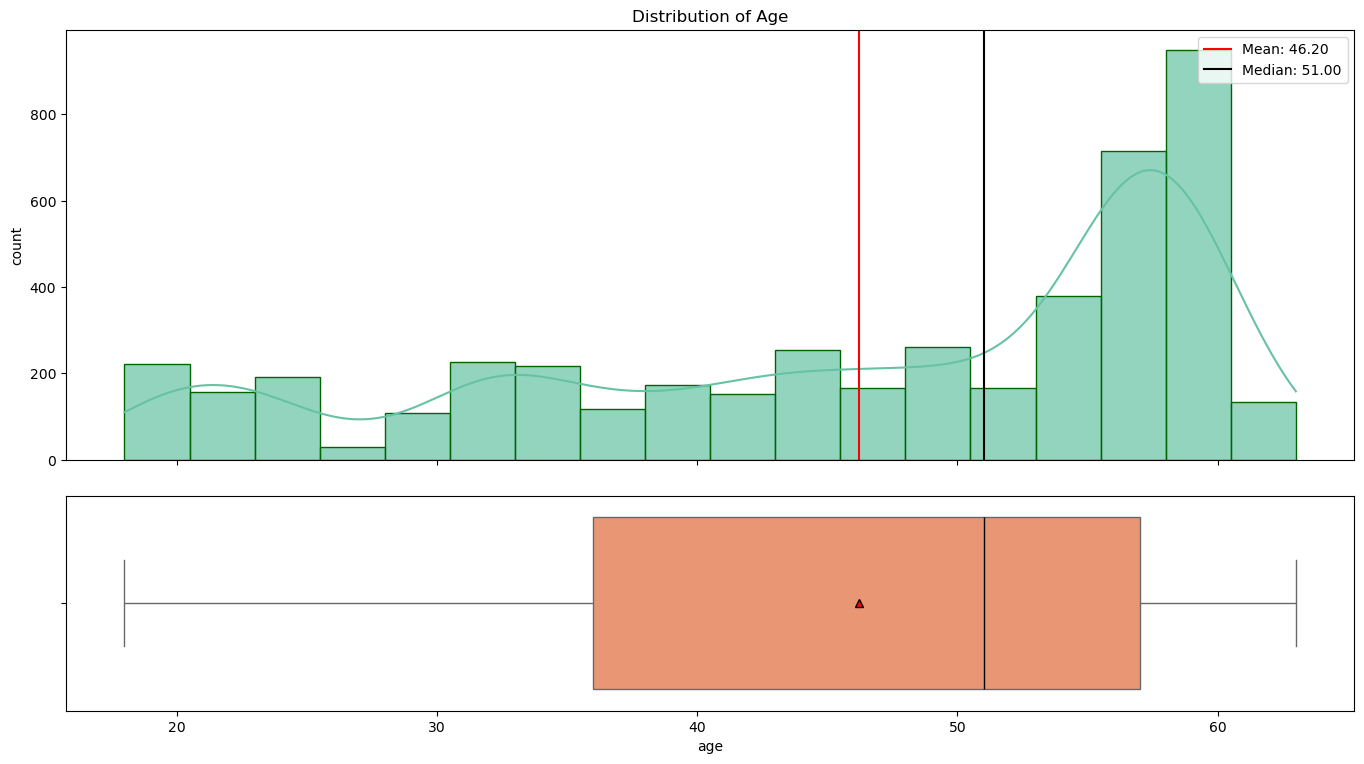

Mean: 46.20, Std: 13.16, Min: 18.00, Max: 63.00, Median: 51.00


In [121]:
# Visualizing the distribution and identifying outliers for the 'age' feature using histogram and boxplot
feature = "age"
plot_histbox(df, feature)

**Observations**:
- The average age of leads is 46 years, with a range from 18 to 63 years and a median of 51 years.
- The distribution is left-skewed, indicating a tilt towards younger ages, as evidenced by the mean being less than the median.
- Despite the left skewness, there’s a significant concentration of ages in the 50 to 60 year range.
- The boxplot indicates no outliers, showing a relatively even spread within the expected age range.

#### Column | website_visits

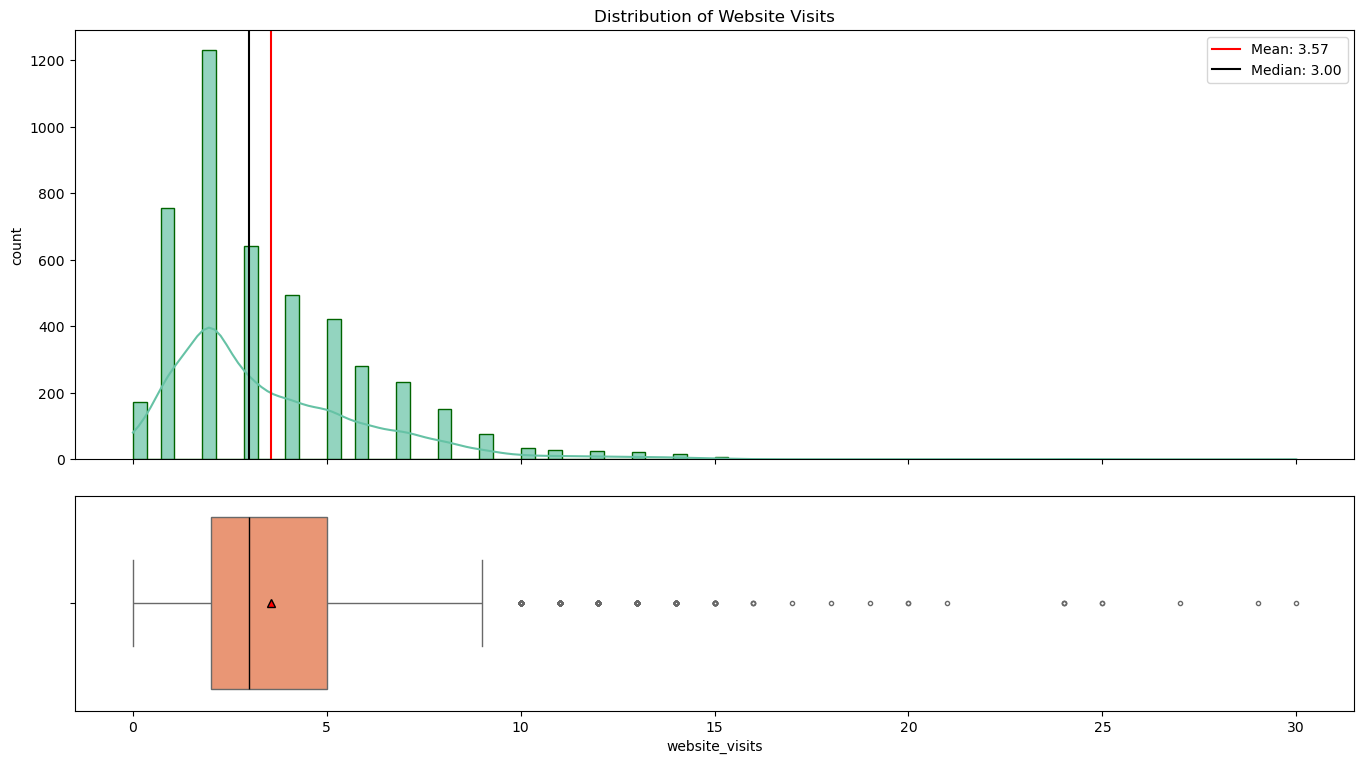

Mean: 3.57, Std: 2.83, Min: 0.00, Max: 30.00, Median: 3.00


In [122]:
# Visualizing the distribution and identifying outliers for the 'website_visits' feature using histogram and boxplot
feature = "website_visits"
plot_histbox(df, feature)

In [123]:
# Checking the number of leads that have not visited the web-site
df[df["website_visits"] == 0].shape

(174, 14)

**Observations**:
- The average number of website visits is approximately 4, ranging widely from 0 to 30, with a median of 3 visits.
- The distribution is highly right-skewed, indicated by a mean greater than the median.
- Most leads record a few website visits, but there is a long tail to the right, showing that a minority of leads have a high number of visits.
- The boxplot reveals several outliers beyond the whiskers, highlighting leads with an unusually high number of visits, some reaching up to 30 visits.

#### Column | time_spent_on_website

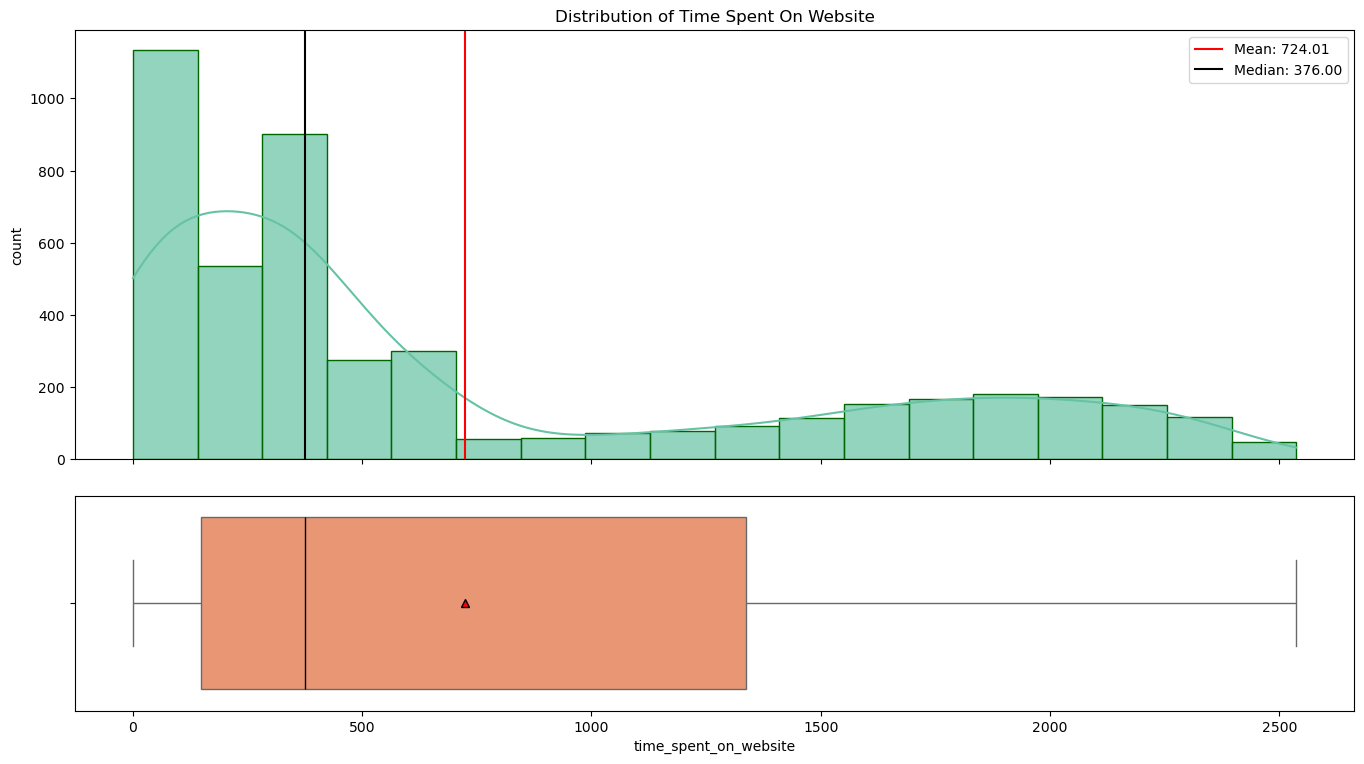

Mean: 724.01, Std: 743.83, Min: 0.00, Max: 2537.00, Median: 376.00


In [124]:
# Visualizing the distribution and identifying outliers for the 'time_spent_on_website' feature using histogram and boxplot
feature = "time_spent_on_website"
plot_histbox(df, feature)

**Observations:**

- On average, leads spent 12 minutes (724 seconds) on the website, with times ranging from 0 to 42 minutes (2537 seconds) and a median of 6 minutes (376 seconds).
- The data show a highly right skewed distribution, with the mean significantly higher than the median.
- The majority of observations are clustered towards shorter visit durations on the left, but there is a long tail extending up to 42 minutes (2537 seconds).
- The absence of outliers in the boxplot indicates that even the highest values, while being on the extreme end, fall within a typical range for this dataset.

#### Column | page_views_per_visit

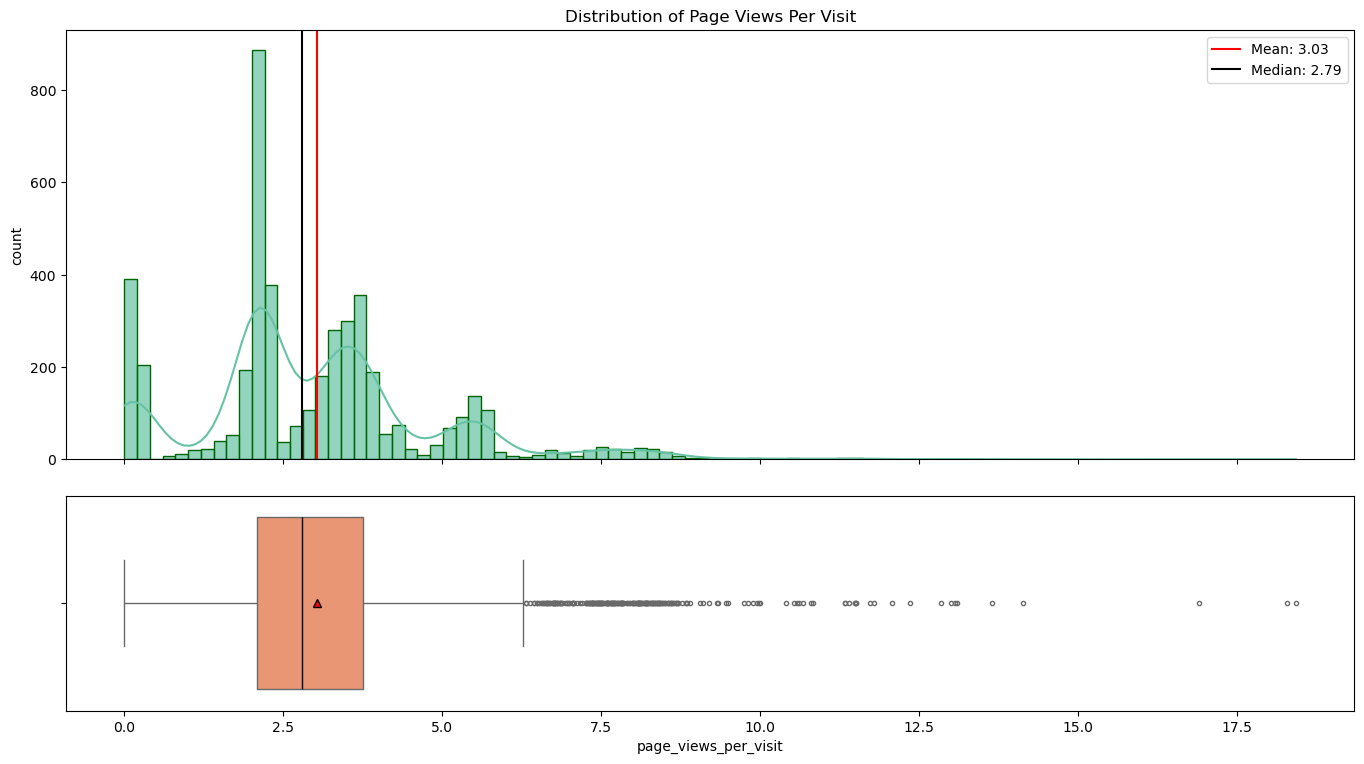

Mean: 3.03, Std: 1.97, Min: 0.00, Max: 18.43, Median: 2.79


In [125]:
# Visualizing the distribution and identifying outliers for the 'page_views_per_visit' feature using histogram and boxplot
feature = "page_views_per_visit"
plot_histbox(df, feature)

**Observations**:

- Users generally view about 2 to 3 pages per visit, though some view as many as 18 pages.
- The distribution is right skewed, with the mean significantly exceeding the median.
- Most observations are concentrated between 0 and 5 page views per visit, but there is a long tail extending to higher values.
- The boxplot shows many outliers, indicating that while the majority of users view only a few pages, there is a distinct group of users who view a significantly higher number of pages. This suggests varied user engagement across the dataset.

### Univariate Analysis of Categorical Columns

In [126]:
# Defining a function to plot categorical variables (barplot and relative percentage annotation)
def barplot_subplots(data, features, perc=False):

    num_features = len(features)
    num_cols = int(math.ceil(math.sqrt(num_features))) if num_features != 3 else 3
    num_rows = int(math.ceil(num_features / num_cols))

    # Adjust the height based on the number of rows
    height = 10 if num_rows > 1 else 5

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, height))
    axes = axes.flatten() if num_features > 1 else [axes]

    for i, feature in enumerate(features):
        total = len(data[feature])
        order = data[feature].value_counts().index

        ax = axes[i]
        sns.countplot(
            data=data,
            x=feature,
            ax=ax,
            palette=palette_color,
            alpha=palette_alpha,
            order=order,
        )

        # Add title for each subplot
        formatted_title = feature.replace("_", " ").title()
        ax.set_title(formatted_title)

        # Convert x-axis labels to lowercase
        ax.set_xticklabels([label.get_text().lower() for label in ax.get_xticklabels()])

        # Annotate each bar by percentage or count
        for container in ax.containers:
            if perc:
                labels = [
                    f"{100 * height / total:.1f}%" for height in container.datavalues
                ]
            else:
                labels = [f"{height:.0f}" for height in container.datavalues]
            ax.bar_label(container, labels=labels, label_type="edge", fontsize=10)

    # Hide any unused subplots
    for j in range(num_features, num_rows * num_cols):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=2.0)
    plt.suptitle("Distribution of Categorical Features", y=1.01, fontsize=14)
    plt.show()

#### Columns | current_occupation, first_interaction, profile_completed, last_activity

In [127]:
# Adding the numerical variable 'status' to the list of categorical columns due to its binary nature.
cat_cols.append("status")

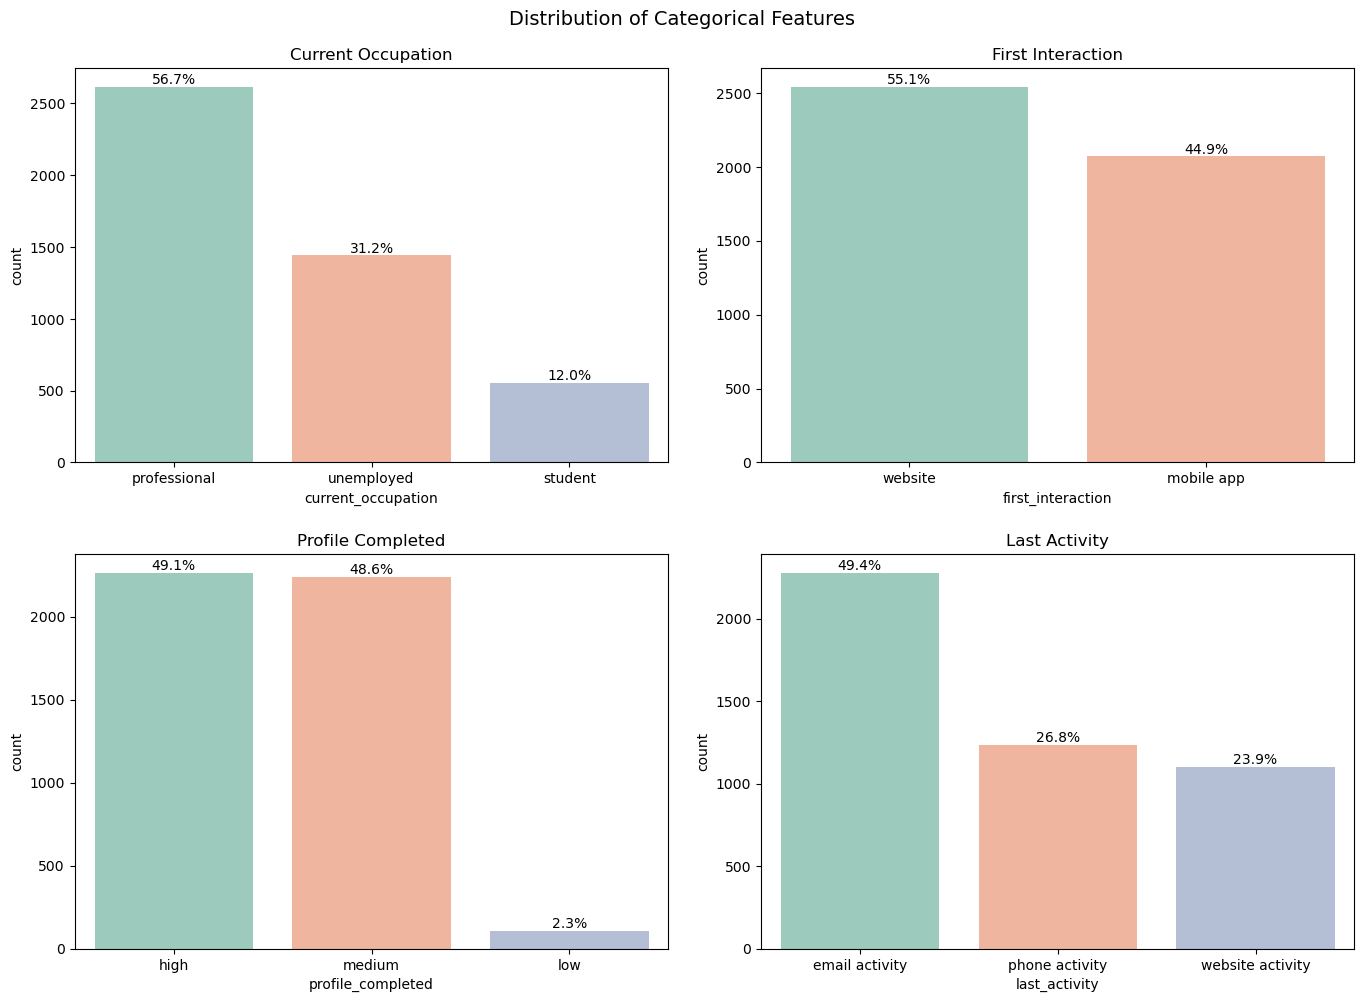

In [128]:
# Plotting barplots for the first four categorical columns
barplot_subplots(df, cat_cols[0:4], perc=True)

**Observations**:

- The majority of leads are professionals, comprising over half of the total lead base, followed by unemployed individuals and students.
- There is a slight preference for leads to first interact through the website rather than the mobile app, though the distribution between these two modes of interaction is relatively balanced.
- Profile completion levels are nearly evenly split between high and medium, with only a small fraction of leads showing low completion rates.
- Email-related activities account for the last recorded interaction for nearly half of the leads, while phone and website interactions represent smaller but significant proportions.

#### Columns | print_media_type1, print_media_type2, digital media, educational_channels

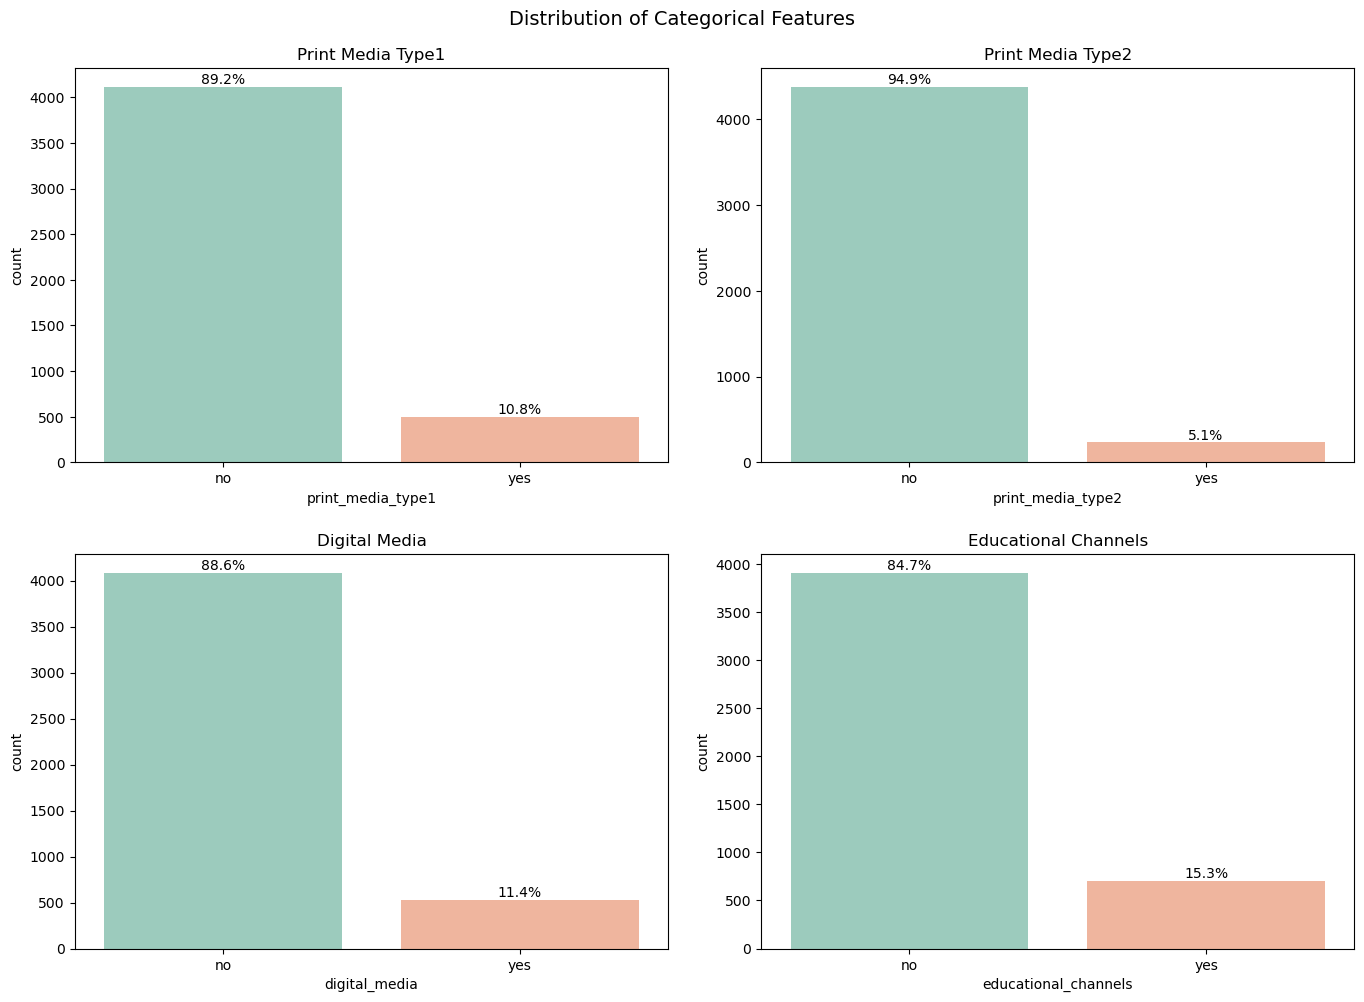

In [129]:
# Plotting barplots for the next four categorical columns
barplot_subplots(df, cat_cols[4:8], perc=True)

**Observations**:

- The majority of leads, 89.2%, did not engage with print media type 1, indicating limited reach.
- An even greater majority, 94.9%, did not engage with print media type 2, suggesting very low engagement.
- Digital media has slightly higher engagement at 88.6%, but it still remains low.
- Educational channels have the highest engagement among the media types shown, yet they are still underutilized by a majority of leads, with 84.7% not engaging.
- Across all media types, the majority of leads show no engagement, highlighting potential areas for increasing outreach and effectiveness.

#### Columns | digital_media, educational_channels, referral

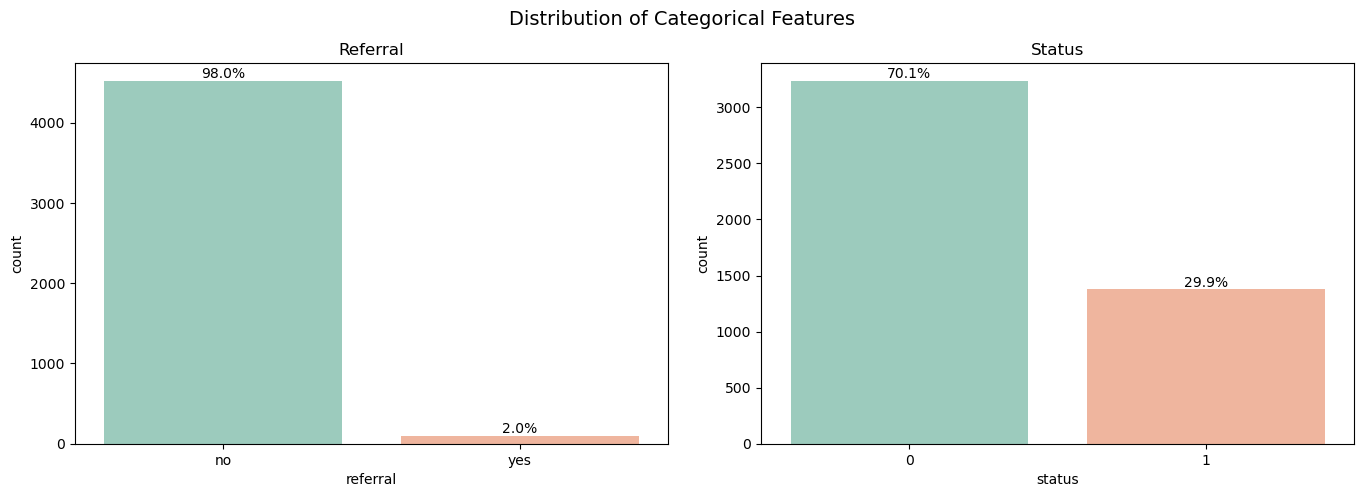

In [130]:
# Plotting barplots for the remaining categorical columns
barplot_subplots(df, cat_cols[8::], perc=True)

**Observations**:
- The vast majority of leads, 98.0%, were not referred by someone else, suggesting that referral strategies might be underutilized or ineffective.
- The majority of leads are non-converted, 70.1%, while only 29.9% are converted. This indicates that less than one-third of the leads convert, pointing to potential areas for improving lead nurturing and conversion tactics.

In [131]:
# Removing the numerical variable 'status' to the list of categorical columns.
cat_cols.remove("status")

### Multivariate Analysis


In [132]:
# Defining a function to calculate and print the sub-category counts
def ctable(data, predictor, feature):

    sorter = (
        data[feature].value_counts().index[-1]
    )  # Series containing counts of unique values (desc). Index of last entry.
    ctab = pd.crosstab(data[predictor], data[feature], margins=True).sort_values(
        by=sorter
    )

    # Remove the index name and convert index and columns to lowercase
    ctab.index = ctab.index.str.lower()
    ctab.columns = ctab.columns.astype(str).str.lower()
    # ctab.index.name = None  # Ensure no index name

    print("-" * 40)
    print(ctab)
    print("-" * 40)

In [133]:
# Defining a function to plot categorical variables (stacked barplot, crosstab and relative percentage annotation)
def stacked_barplot(data, predictor, feature):

    # Generate the crosstab for plotting
    ctable(data, predictor, feature)

    # Create the crosstab normalized by row ('index')
    ctab = pd.crosstab(data[predictor], data[feature], normalize="index") * 100

    # Plotting the crosstab as a stacked bar plot
    ax = ctab.plot(
        kind="bar",
        stacked=True,
        rot=0,
        figsize=(10, 5),
        color=palette_color,
        alpha=palette_alpha,
    )

    # Convert x-axis labels to lowercase
    ax.set_xticklabels([label.get_text().lower() for label in ax.get_xticklabels()])

    # Adjust the legend position
    ax.legend(title="status", bbox_to_anchor=(0.92, 0.98), loc="upper left")

    # Annotate each bar by percentage
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", label_type="center", fontsize=10)

    # Add title for each subplot
    formatted_predictor = predictor.replace("_", " ").title()
    formatted_feature = feature.replace("_", " ").title()

    plt.title(f"Distribution of {formatted_predictor} by {formatted_feature}")
    plt.ylabel("percentage")
    plt.xlabel(predictor)
    plt.tight_layout(pad=2.0)
    plt.show()

In [134]:
# Defining a function to create a boxplot (with statistical analysis)
def boxplot_stats(data, predictor, target):

    stat = (
        data.groupby([predictor])[target]
        .describe()
        .sort_values(by=("mean"), ascending=False)
    )
    print("-" * 80)
    print(stat)
    print("-" * 80)

    meanprops = {"markerfacecolor": "red", "markeredgecolor": "black"}

    plt.figure(figsize=(10, 5))
    ax = sns.boxplot(
        data=data,
        x=predictor,
        y=target,
        showmeans=True,
        meanprops=meanprops,
        hue=predictor,
        palette=palette_color,
    )

    # Convert x-axis labels to lowercase
    ax.set_xticklabels([label.get_text().lower() for label in ax.get_xticklabels()])

    # Add title for each subplot
    formatted_predictor = predictor.replace("_", " ").title()
    formatted_target = target.replace("_", " ").title()

    plt.title(f"Distribution of {formatted_predictor} by {formatted_target}")
    plt.tight_layout(pad=2.0)
    plt.show()

In [135]:
# Defining a function to plot distributiona and boxplot with respect to target variable (binary)
def distplot_boxplot_target(
    df, predictor, target, figsize=(11, 11), kde=True, hratio=(1, 1.5, 1.5)
):

    # Create a subplot layout with 1 big plot on top and 2 smaller plots below
    plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(3, 2, height_ratios=hratio)

    # Initialization
    axes = []  # Empty list to store axes
    skewness = []  # Empty list to store skewness
    meanprops = {"markerfacecolor": "red", "markeredgecolor": "black"}

    # Extract unique target values
    target_uniq = sorted(df[target].unique())

    # Boxplot
    ax1 = plt.subplot(gs[0, :])
    sns.boxplot(
        data=df,
        x=target,
        y=predictor,
        showmeans=True,
        meanprops=meanprops,
        palette=palette_color,
        ax=ax1,
    )

    # Add title for each subplot
    formatted_predictor = predictor.replace("_", " ").title()
    formatted_target = target.replace("_", " ").title()
    ax1.set_title((f"Distribution of {formatted_predictor} by {formatted_target}"))
    axes.append(ax1)

    # Histplots
    for i, tvalue in enumerate(target_uniq):
        df_temp = df[df[target] == tvalue]

        # Calculate key statistics
        fstats = df_temp[predictor].describe()
        fstats = fstats.loc[["mean", "50%"]].to_dict()
        fstats["median"] = fstats.pop("50%")  # Rename the '50%' key to 'median'
        skew = df_temp[predictor].skew()

        ax = plt.subplot(gs[1, i])
        sns.histplot(data=df_temp, kde=kde, x=predictor, color=palette_color[i], ax=ax)
        ax.set_title(f"{target} = [{tvalue}]")
        ax.set_xlabel(predictor)
        ax.set_ylabel("count")

        # Add lines for mean and median values
        ax.axvline(
            fstats["mean"],
            color="red",
            linestyle="-",
            linewidth=1.5,
            label=f"Mean: {fstats['mean']:.2f}",
        )
        ax.axvline(
            fstats["median"],
            color="black",
            linestyle="-",
            linewidth=1.5,
            label=f"Median: {fstats['median']:.2f}",
        )
        ax.legend()
        axes.append(ax)
        skewness.append(skew)

    # Adjust layout
    plt.tight_layout(pad=2.0)
    plt.show()

    # Print the key statistics and skewness for each target category
    for i, tvalue in enumerate(target_uniq):
        fstats_str = ", ".join(
            [f"{key.capitalize()}: {value:.2f}" for key, value in fstats.items()]
        )
        print(
            f"{target} = [{tvalue}] | {fstats_str}, Skewness: {np.round(skewness[i], 2)}"
        )

#### Columns | age, website_visits, time_spent_on_website, page_views_per_visit, status

In [136]:
# Select relevant features
relevant_features = num_cols[:]

# Calculate correlation matrix for numerical features
corr = df[relevant_features].corr().round(2)

# Convert the correlation matrix into a DataFrame and rename the 'index' colum
corr_df = corr.reset_index().rename(columns={"index": "numerical_feature"})

# Display the correlation matrix
display(corr_df)

,numerical_feature,age,website_visits,time_spent_on_website,page_views_per_visit,status
0,age,1.00,-0.01,0.02,-0.04,0.12
1,website_visits,-0.01,1.00,0.06,0.07,-0.01
2,time_spent_on_website,0.02,0.06,1.00,0.07,0.30
3,page_views_per_visit,-0.04,0.07,0.07,1.00,0.00
4,status,0.12,-0.01,0.30,0.00,1.00


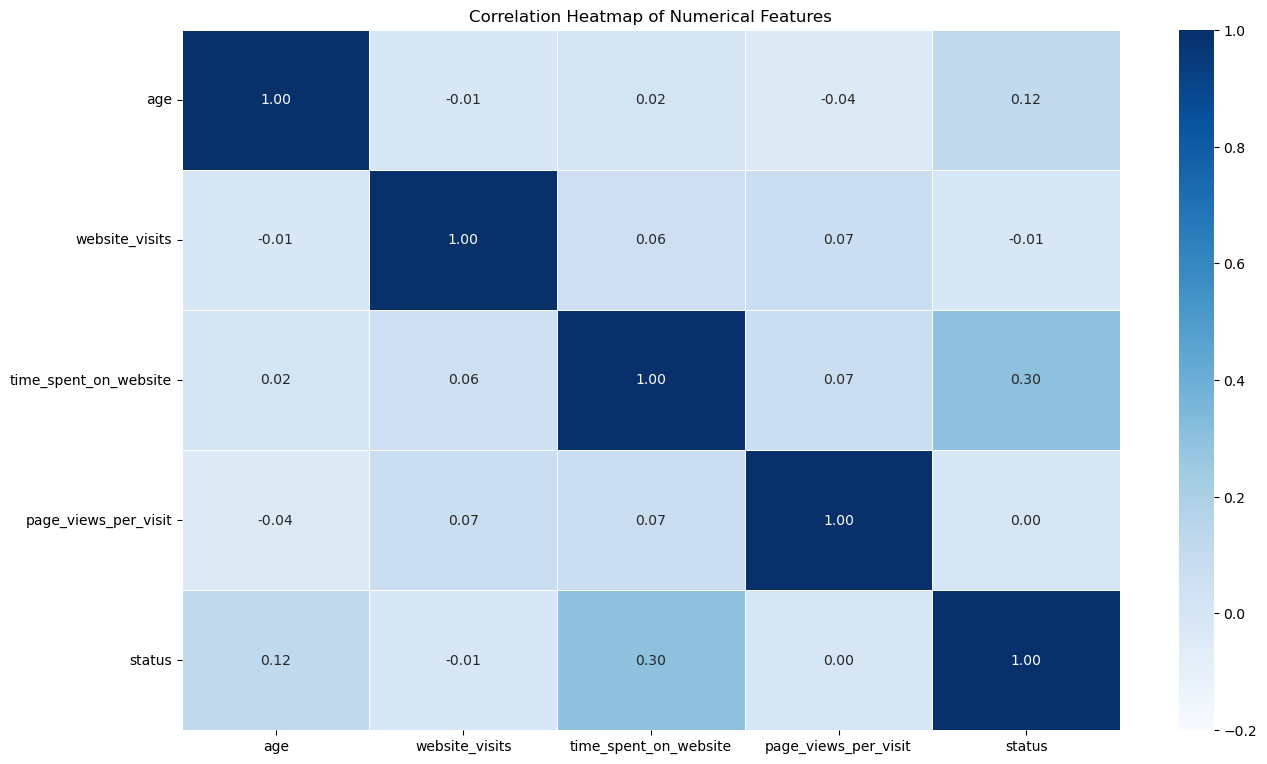

In [137]:
# Plot the correlation heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(data=corr, annot=True, linewidths=0.5, fmt=".2f", vmin=-0.2, cmap="Blues")

# Add title
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout(pad=2.0)
plt.show()

**Observations**:<br><br>
The heatmap shows the correlation coefficients between different numerical features in the dataset. The color scale ranges from -1 (perfect negative correlation) to 1 (perfect positive correlation), with 0 indicating no correlation.

- Most features have weak or no significant correlations with each other, as indicated by the correlation values close to 0.
- Weak positive correlation, 0.12, between **age** and **status**, suggesting that older leads are slightly more likely to be converted to paid customers.
- Moderate positive correlation, 0.30,  between **time_spent_on_website** and **status**, indicating that leads who spend more time on the website are more likely to be converted to paid customers.

#### Columns | current_occupation vs. status

----------------------------------------
status                 0     1   all
current_occupation                  
student              490    65   555
unemployed          1058   383  1441
professional        1687   929  2616
all                 3235  1377  4612
----------------------------------------


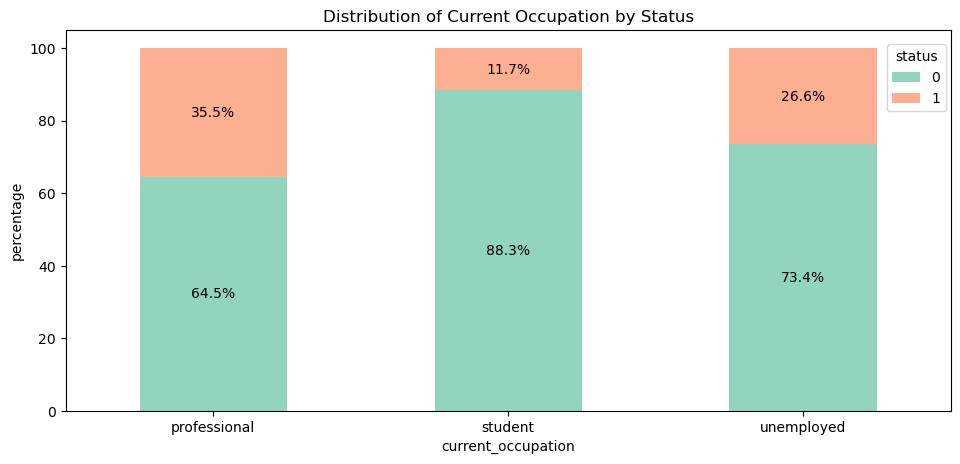

In [138]:
stacked_barplot(df, "current_occupation", "status")

**Observations**:
- The stacked bar plot clearly shows that the current occupation plays a significant role in lead engagement and conversion rates.
- Professionals have the highest conversion rate at 35.5%, followed by unemployed at 26.6%, while students have the lowest conversion rate at 11.7%.
- The lower conversion rate among students suggests that different engagement strategies might be needed for this group.

#### Columns | current_occupation vs. age

--------------------------------------------------------------------------------
                     count       mean       std   min   25%   50%   75%   max
current_occupation                                                           
Unemployed          1441.0  50.140180  9.999503  32.0  42.0  54.0  58.0  63.0
Professional        2616.0  49.347477  9.890744  25.0  42.0  54.0  57.0  60.0
Student              555.0  21.144144  2.001114  18.0  19.0  21.0  23.0  25.0
--------------------------------------------------------------------------------


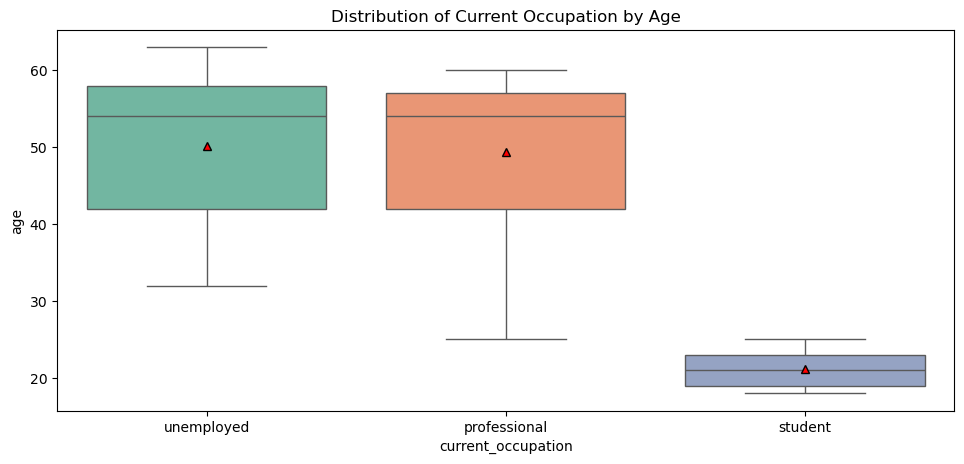

In [139]:
boxplot_stats(df, "current_occupation", "age")

**Observations**:<br>

- The box plot and statistical summary provide a clear view of the age distributions across different occupation categories.
- Unemployed leads typically center around a median age of 54 years, with most falling between 42 and 58 years.
- Professional leads also show a median age of 54 years, indicating a predominance of a mature age group, similar to unemployed leads.
- Student leads are considerably younger, with their ages tightly clustered around 21 years.
- Both unemployed and professional leads share a mature age profile, with median ages around 54 years and comparable interquartile ranges, suggesting similar age distributions. In contrast, student leads demonstrate a distinctly younger demographic, primarily concentrated in the early twenties.

#### Columns | first_interaction vs. status

----------------------------------------
status                0     1   all
first_interaction                  
mobile app         1852   218  2070
website            1383  1159  2542
all                3235  1377  4612
----------------------------------------


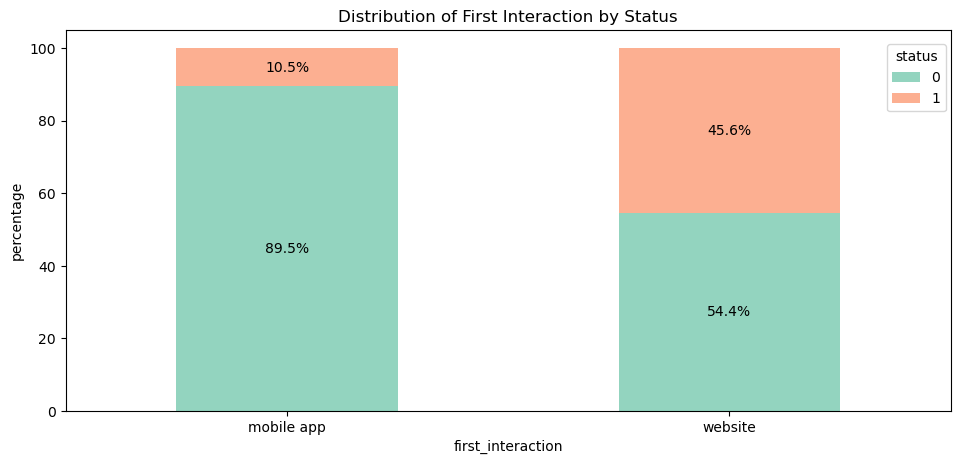

In [140]:
stacked_barplot(df, "first_interaction", "status")

**Observations**:<br>

- The stacked bar plot clearly shows that the channel of first interaction plays a significant role in lead engagement and conversion rates.
- Leads whose first interaction was via the website show a much higher conversion rate at 45.6% compared to 10.5% for those whose first interaction was via the mobile app.
- The high conversion rate of the website suggests that this channel is a more engaging and potentially more informative platform for initial interactions.

#### Columns | profile_completed vs. status

----------------------------------------
status                0     1   all
profile_completed                  
low                  99     8   107
medium             1818   423  2241
high               1318   946  2264
all                3235  1377  4612
----------------------------------------


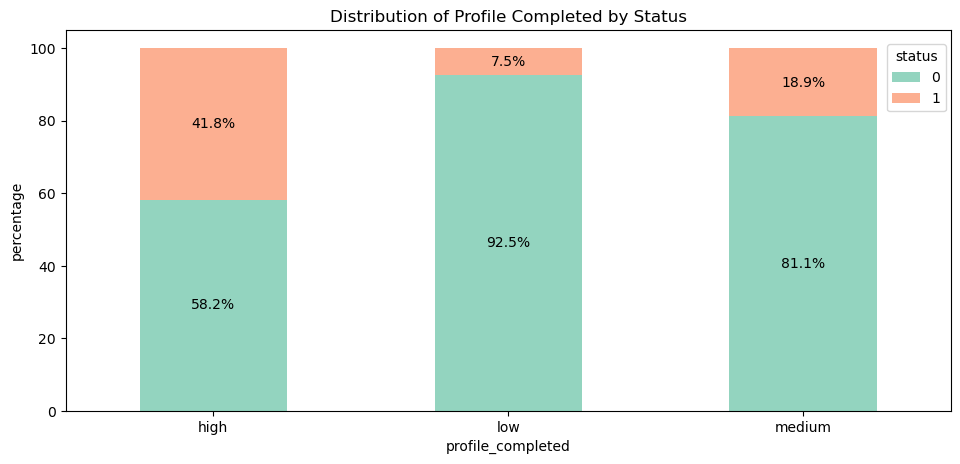

In [141]:
stacked_barplot(df, "profile_completed", "status")

**Observations**:<br>

- The stacked bar plot clearly demonstrates the strong correlation between profile completion levels and lead conversion rates.
- Leads with a high profile completion rate have the highest conversion rate at 41.8%, followed by those with a medium profile completion rate at 18.9%, while those with a low profile completion rate have the lowest conversion rate at 7.5%.
- Higher profile completion rates are significantly correlated with higher conversion rates, suggesting that encouraging leads to complete their profiles could be an effective strategy for improving engagement and conversion.

#### Columns | last_activity vs. status

----------------------------------------
status               0     1   all
last_activity                     
phone activity     971   263  1234
website activity   677   423  1100
email activity    1587   691  2278
all               3235  1377  4612
----------------------------------------


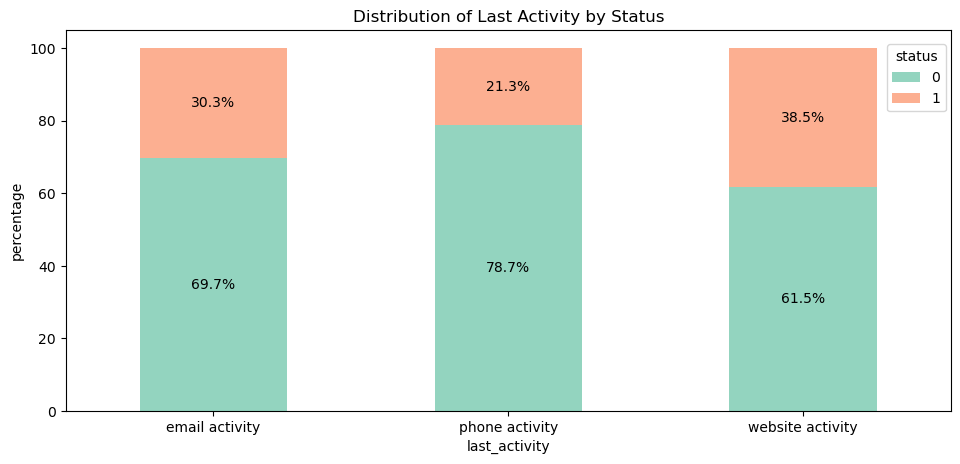

In [142]:
stacked_barplot(df, "last_activity", "status")

**Observations**:<br>

- The stacked bar plot demonstrates that the type of last activity significantly influences lead conversion rates.
- Leads whose last activity was website-related have the highest conversion rate at 38.5%, followed by those with email activity at 30.3%, while leads with phone activity have the lowest conversion rate at 21.3%.
- Recent website activity is highly correlated with higher conversion rates, suggesting that maintaining an active presence on the website could be an effective strategy for improving engagement and conversion.

#### Column | age vs. status

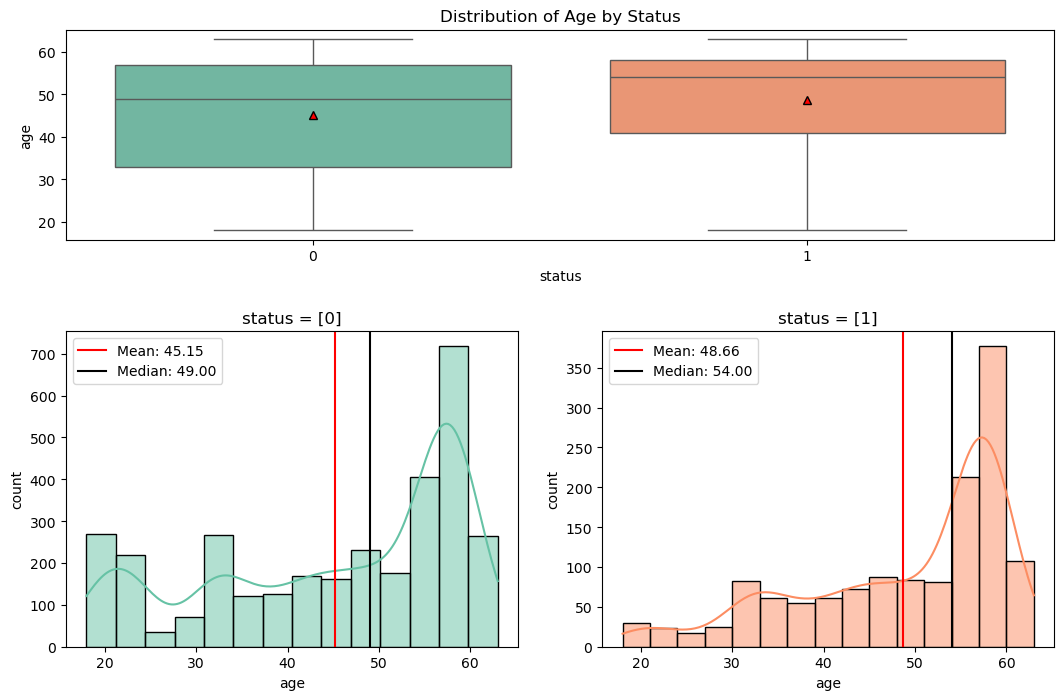

status = [0] | Mean: 48.66, Median: 54.00, Skewness: -0.6
status = [1] | Mean: 48.66, Median: 54.00, Skewness: -0.95


In [143]:
distplot_boxplot_target(df, "age", "status")

**Observations**:<br>

- Both distributions of age for leads are left-skewed. The distribution for non-converted leads is multimodal, showing peaks at both younger and older ages, while the distribution for converted leads is single-peaked with a high concentration at older ages.
- There are no significant outliers in either distribution, indicating consistent age ranges within each status group.
- Converted leads tend to be older, as evidenced by higher mean and median ages, suggesting that age is a significant factor in lead conversion.
- This suggests that targeting older leads could be beneficial for improving conversion rates.

#### Columns | website_visits vs. status

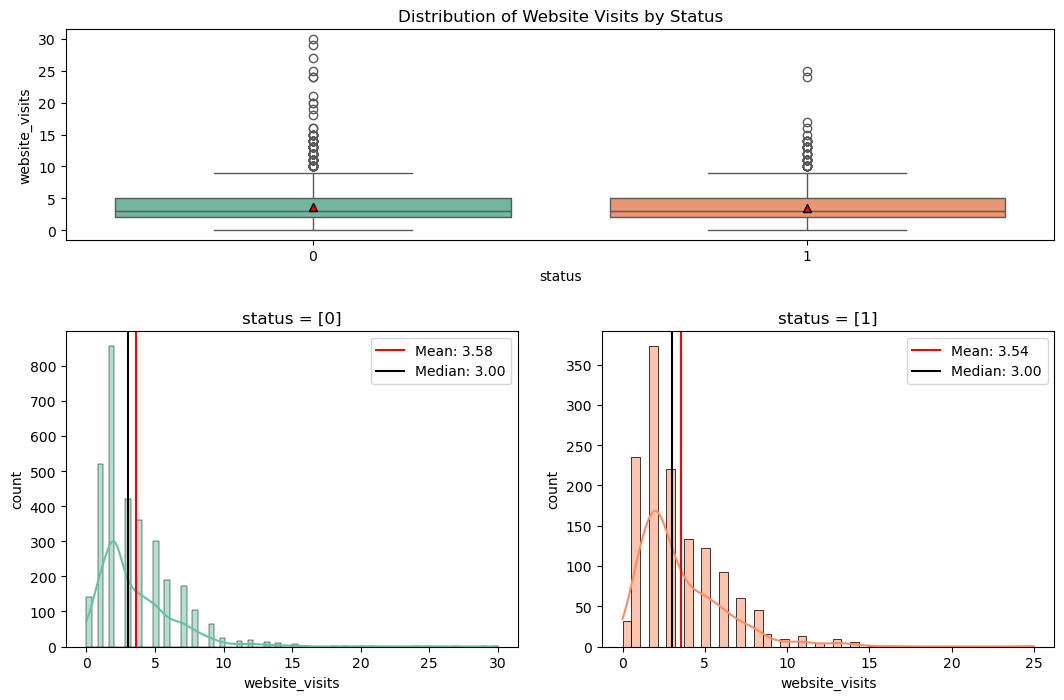

status = [0] | Mean: 3.54, Median: 3.00, Skewness: 2.22
status = [1] | Mean: 3.54, Median: 3.00, Skewness: 1.98


In [144]:
distplot_boxplot_target(df, "website_visits", "status")

**Observations**:<br>
- Both distributions of website visits for leads are right skewed with the majority of website visits at the lower end. 
- Converted leads tend to have more website visits compared to non-converted leads, as indicated by higher medians and means.
- Both groups have a significant number of outliers, indicating a few leads with very high engagement in terms of website visits.
- This suggests that frequent visits and in-depth browsing can serve as a strong indicator of higher engagement and potential conversion.

#### Columns | time_spent_on_website vs. status

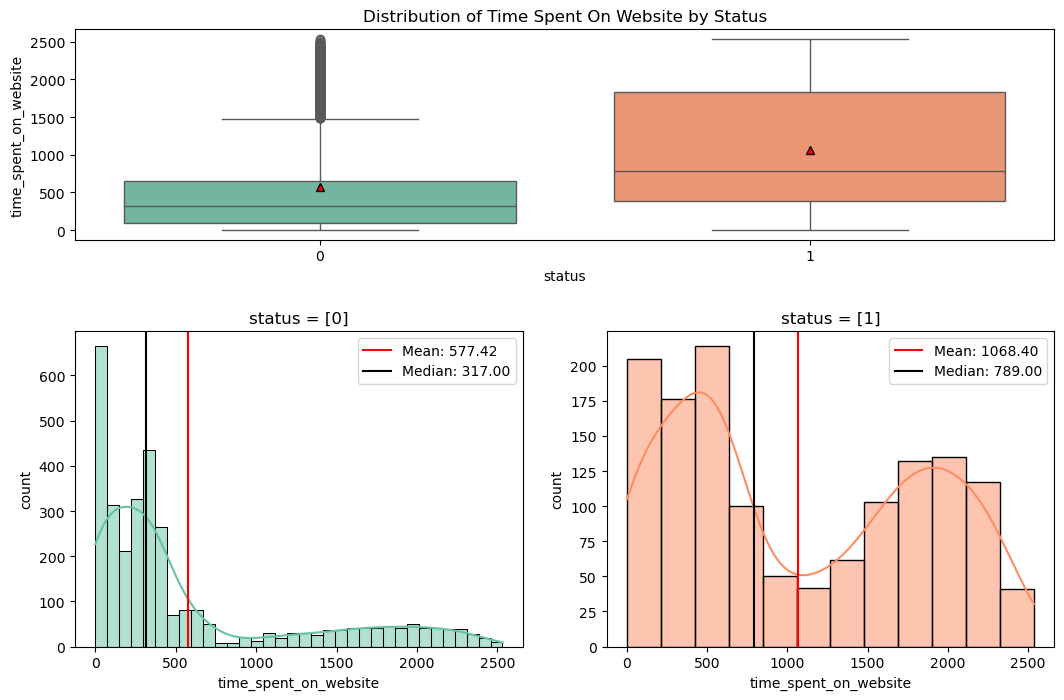

status = [0] | Mean: 1068.40, Median: 789.00, Skewness: 1.4
status = [1] | Mean: 1068.40, Median: 789.00, Skewness: 0.23


In [145]:
distplot_boxplot_target(df, "time_spent_on_website", "status")

**Observation**:<br>

- The distribution of time spent on the website for non-converted leads is right-skewed with many outliers, indicating a few leads with very high engagement.
- The distribution for converted leads is right-skewed and bimodal, with concentrations of observations around the 8-minute (500s) and 30-minute (1800s) marks.
- Converted leads tend to spend significantly more time on the website compared to non-converted leads, as indicated by higher medians and means.
- This suggests that extended and consistent browsing is a strong indicator of higher engagement and potential conversion.

#### Columns | page_views_per_visit vs. status 

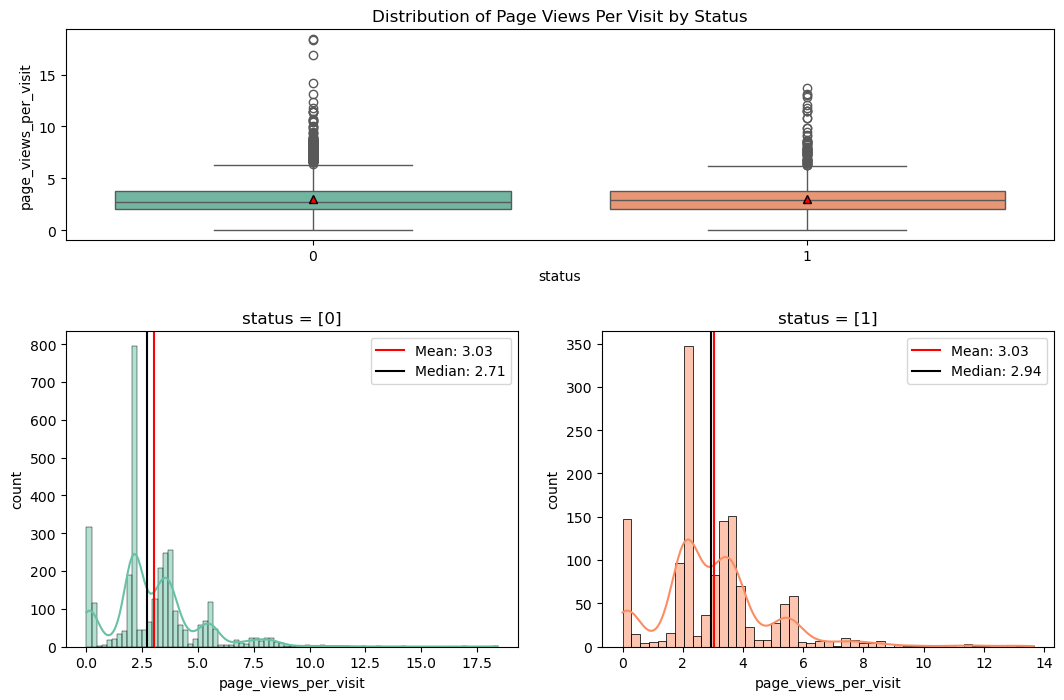

status = [0] | Mean: 3.03, Median: 2.94, Skewness: 1.26
status = [1] | Mean: 3.03, Median: 2.94, Skewness: 1.29


In [146]:
distplot_boxplot_target(df, "page_views_per_visit", "status")

**Observations**:<br>

- Both distributions are right-skewed, indicating that while the majority of leads view fewer pages, there is a long tail extending towards higher values. 
- Each distribution also exhibits a multimodal character, which suggests the presence of several peaks or modes, reflecting varied browsing behaviors among the leads.
- Converted leads tend to have more page views per visit compared to non-converted leads, as indicated by higher medians and means.
- This correlation suggests that frequent and in-depth browsing is a strong indicator of higher engagement and potential conversion.
- The outliers in both groups show that while most leads have moderate page views, a few highly engaged leads indicate exceptional engagement.

#### Columns | print_media_type1 vs. status

----------------------------------------
status                0     1   all
print_media_type1                  
yes                 338   159   497
no                 2897  1218  4115
all                3235  1377  4612
----------------------------------------


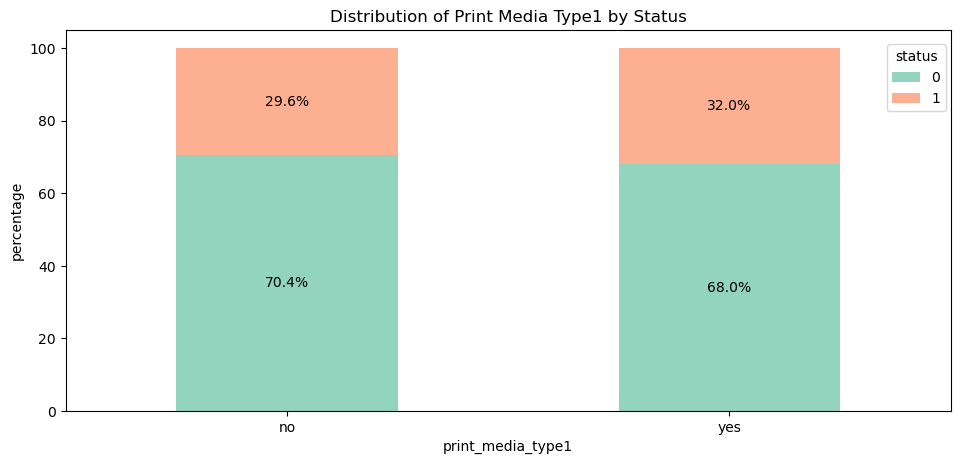

In [147]:
stacked_barplot(df, "print_media_type1", "status")

**Observations**:<br>

- Exposure to print media type 1 appears to have a marginally positive effect on lead engagement and conversion rates.
- In numbers, leads exposed to print media type 1 show a slightly higher conversion rate of 32.0% compared to 29.6% for those not exposed.

#### Columns | print_media_type2 vs. status

----------------------------------------
status                0     1   all
print_media_type2                  
yes                 158    75   233
no                 3077  1302  4379
all                3235  1377  4612
----------------------------------------


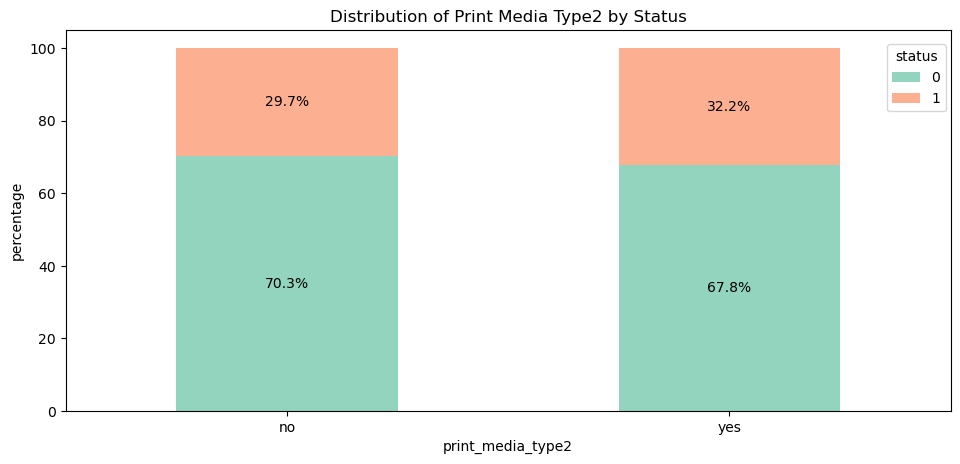

In [148]:
stacked_barplot(df, "print_media_type2", "status")

**Observations**:<br>

- Exposure to print media type 2 appears to have a marginally positive effect on lead engagement and conversion rates.
- In numbers, leads exposed to print media type 2 show a slightly higher conversion rate of 32.2% compared to 29.7% for those not exposed.
- This outcome mirrors that of print media type 1, where exposure similarly results in a marginally higher conversion rate.

#### Columns | digital_media vs. status

----------------------------------------
status            0     1   all
digital_media                  
yes             359   168   527
no             2876  1209  4085
all            3235  1377  4612
----------------------------------------


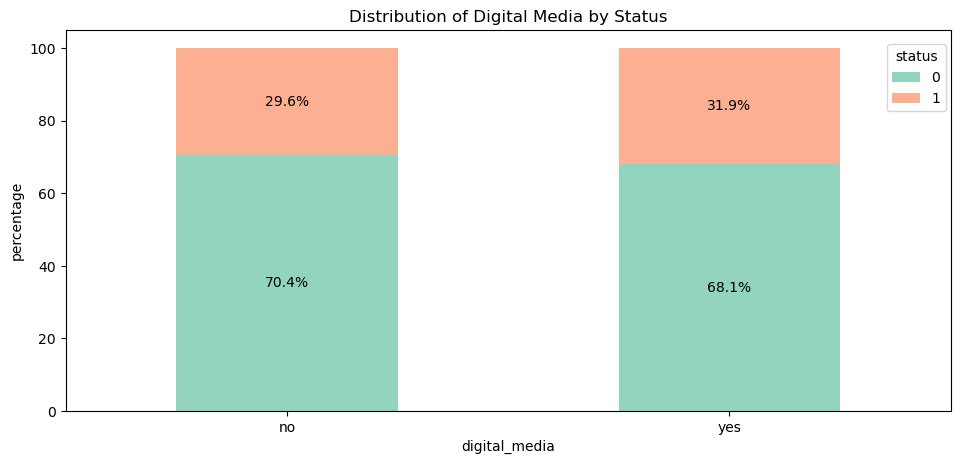

In [149]:
stacked_barplot(df, "digital_media", "status")

**Observations**:<br>

- Exposure to digital media appears to have a marginally positive effect on lead engagement and conversion rates.
- In numbers, leads exposed to digital media show a slightly higher conversion rate of 31.9% compared to 29.6% for those not exposed.
- This outcome mirrors that of print media type 1 and 2, where exposure similarly results in a marginally higher conversion rate.

#### Columns | educational_channels vs. status

----------------------------------------
status                   0     1   all
educational_channels                  
yes                    508   197   705
no                    2727  1180  3907
all                   3235  1377  4612
----------------------------------------


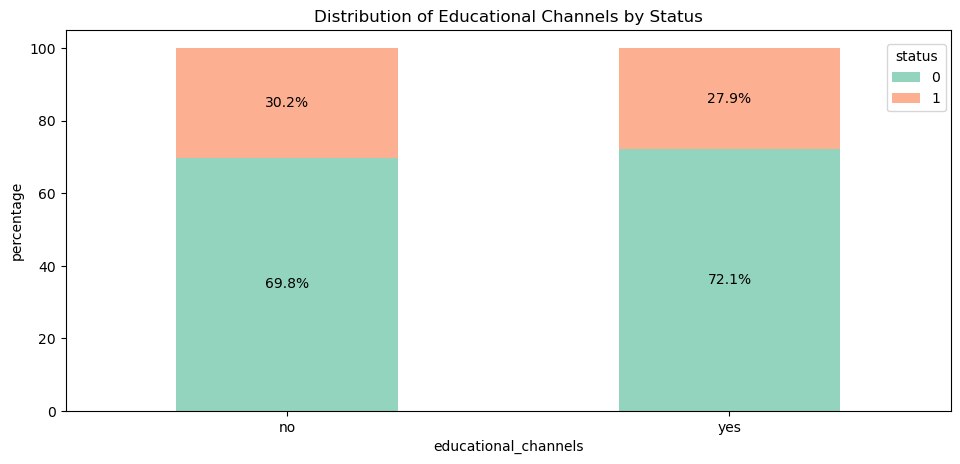

In [150]:
stacked_barplot(df, "educational_channels", "status")

**Observations**:<br>

- Exposure to educational channels appears to have a marginally negative effect on lead engagement and conversion rates.
- In numbers, leads exposed to digital media show a slightly lower conversion rate of 27.9% compared to 30.2% for those not exposed.
- This suggests that educational channels may not be the most effective tool for increasing lead engagement and conversion rates.


#### Columns | referral vs. status

----------------------------------------
status       0     1   all
referral                  
yes         30    63    93
no        3205  1314  4519
all       3235  1377  4612
----------------------------------------


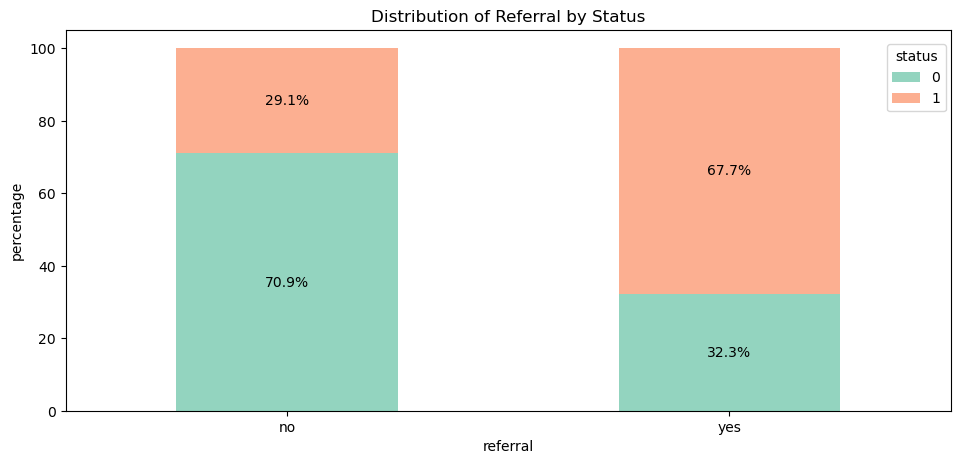

In [151]:
stacked_barplot(df, "referral", "status")

**Observations**:<br>

- Referrals appear to have a strongly positive effect on lead conversion rates.
- In numbers, leads who received referrals show a much higher conversion rate of 67.7% compared to 29.1% for those who did not.
- This suggests that leveraging referral programs could be highly effective for engagement and lead conversion strategies.


### Outlier Analysis

In [152]:
# Selecte numerical variables
num_data = df[num_cols].drop(columns=["status"])

# Calculate quartiles and IQR
Q1 = num_data.quantile(0.25)
Q3 = num_data.quantile(0.75)
IQR = Q3 - Q1

# Find lower and upper bounds for outliers
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Outliers | Out of Bounds Percentage
----------------------------------------
age                      0.00
website_visits           3.34
time_spent_on_website    0.00
page_views_per_visit     5.57
dtype: float64
----------------------------------------


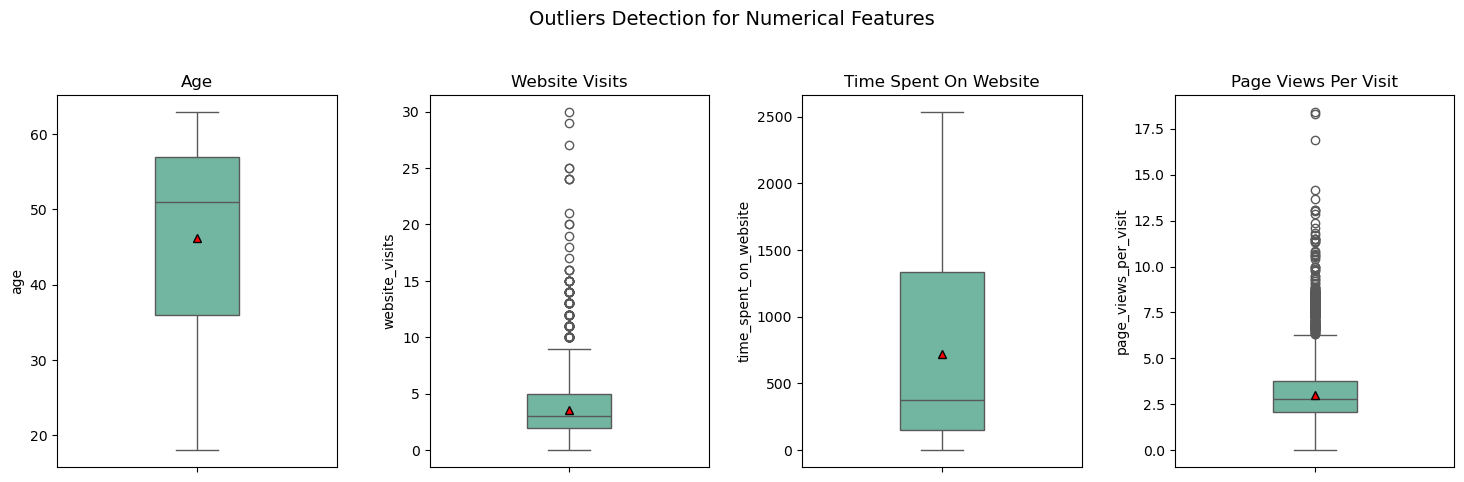

In [153]:
# Calculate the percentage of outliers for each numerical variable
out_of_bounds_percentage = ((num_data < lower) | (num_data > upper)).mean() * 100
print("Outliers | Out of Bounds Percentage")
print("-" * 40)
print(out_of_bounds_percentage.round(2))
print("-" * 40)

# Set figure size
plt.figure(figsize=(15, 5))

# Properties for mean marker
meanprops = {"markerfacecolor": "red", "markeredgecolor": "black"}
color_hist = [palette_color[0], palette_color[1]]

# Calculate the number of rows and columns for subplots
num_cols = 4
num_rows = int(np.ceil(len(num_data.columns) / num_cols))

# Loop through each numeric column and create a subplot
for i, variable in enumerate(num_data.columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(
        data=df,
        y=variable,
        showmeans=True,
        meanprops=meanprops,
        palette=color_hist,
        width=0.3,
    )
    # Add title for each subplot
    formatted_title = variable.replace("_", " ").title()
    plt.title(formatted_title)

# Add title for the entire plot
plt.suptitle("Outliers Detection for Numerical Features", y=0.98, fontsize=14)

# Adjust layout and show plot
plt.tight_layout(pad=2.0)
plt.show()

**Observations**:

These outliers likely reflect genuine behavior patterns of highly engaged leads. They represent real scenarios of lead behavior and engagement, indicating a lead’s strong interest or need for extensive information before making a decision. The ML models should learn those underlying pattern as well.
- **age, time_spent_on_website**: No outliers present, indicating that both metrics of leads fall within a consistent range without extreme values.
- **website_visits**: Approximately 3.34% of the data points are outliers, indicating a small proportion of leads with unusually high numbers of website visits.
- **page_views_per_visit**: Around 5.57% of the data points are outliers, showing that a notable fraction of leads view significantly more pages per visit.

## Key Insights

- **Impact of Current Occupation**

    Leads’ current occupations strongly influence conversion rates. Professionals exhibit the highest conversion rate at 35.5%, followed by unemployed individuals at 26.6%, while students have the lowest at 11.7%. This highlights the need for tailored strategies to address varying expectations based on occupation.
- **Effect of First Interaction Channel**

    The channel of first interaction significantly impacts engagement and conversion. Leads interacting via the website demonstrate a 45.6% conversion rate, significantly outperforming mobile app interactions at 10.5%. This underscores the website’s role as a more engaging and informative platform.
- **Most Effective Interaction Mode**

    Website-related activities yield the highest conversion rate at 38.5%, followed by email activities at 30.3%, while phone interactions lag at 21.3%. Prioritizing website engagement emerges as the most effective strategy for lead conversion.
- **Performance of Lead Channels**

    Referrals are the most effective channel with a conversion rate of 67.7%, significantly outperforming other sources. Print media, digital media, and educational channels show comparable effectiveness, with conversion rates ranging from 33% to 28%.
- **Influence of Profile Completion**

    Higher levels of profile completion strongly correlate with increased conversion rates. Leads with highly completed profiles convert at 41.8%, compared to 18.9% for medium and 7.5% for low completion levels. Encouraging detailed profile completion could significantly enhance lead engagement and conversion.

## Model Preparation and Setup

This section outlines the model preparation process, including handling a class imbalance in the target variable through stratified sampling to preserve class distributions across train and validation sets. Minor outliers are retained as they reflect real-world behavior, and no missing values were identified, ensuring the dataset is ready for modeling.

**Model Evaluation**

The model’s performance is assessed using a classification report, which highlights metrics such as precision, recall, F1-score, and support for each class. This provides a comprehensive understanding of the model’s accuracy and its ability to balance false positives and false negatives effectively.

**Model Optimization**

To minimize false negatives (Type II Errors) and prevent losing potential customers—a critical business priority—the model is optimized to maximize Recall. By focusing on high-potential leads, this approach balances resource allocation with customer acquisition:
- **Type I Error**: Predicting a lead will convert when it doesn’t, leading to wasted resources.
- **Type II Error**: Predicting a lead won’t convert when it does, resulting in lost customers.

### Data Preprocessing

In [154]:
# Separating the dependent (target) variable and independent variables
X = df.drop(columns=["status"], axis=1)
Y = df["status"]
print(X.shape, Y.shape)

(4612, 13) (4612,)


### Encoding of Categorical Variables

In [155]:
# Creating list of dummy columns (categorical features)
to_get_dummies_for = cat_cols

# Creating dummy variables
X = pd.get_dummies(data=X, columns=to_get_dummies_for, drop_first=True)

# Ensure the target variable is also encoded if it's categorical
if Y.dtype == "object":
    Y = pd.get_dummies(Y, drop_first=True)

# Display the dimensions of the dataset
print(X.shape)

(4612, 16)


In [156]:
# Checking the encoded dataset
X.head()

,age,website_visits,time_spent_on_website,page_views_per_visit,current_occupation_Student,current_occupation_Unemployed,first_interaction_Website,profile_completed_Low,profile_completed_Medium,last_activity_Phone Activity,last_activity_Website Activity,print_media_type1_Yes,print_media_type2_Yes,digital_media_Yes,educational_channels_Yes,referral_Yes
0,57,7,1639,1.861,False,True,True,False,False,False,True,True,False,True,False,False
1,56,2,83,0.320,False,False,False,False,True,False,True,False,False,False,True,False
2,52,3,330,0.074,False,False,True,False,True,False,True,False,False,True,False,False
3,53,4,464,2.057,False,True,True,False,False,False,True,False,False,False,False,False
4,23,4,600,16.914,True,False,True,False,False,False,False,False,False,False,False,False


### Splitting the Data

In [157]:
# Splitting the data (70:30 ratio) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=1, stratify=Y
)

In [158]:
# Assuming y_train and y_test are defined
y_train_distribution = y_train.value_counts(normalize=True).round(3)
y_test_distribution = y_test.value_counts(normalize=True).round(3)

# Combine the distributions into a single data frame
distribution_df = pd.DataFrame(
    {"Training": y_train_distribution, "Testing": y_test_distribution}
)

print("Target Distribution")
print("-" * 40)
print(distribution_df)

Target Distribution
----------------------------------------
        Training  Testing
status                   
0          0.701    0.702
1          0.299    0.298


### Model Evaluation

In [159]:
# Function to print the classification report and calculate the confusion matrix
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    cn_labels = ["Not Converted", "Converted"]

    plt.figure(figsize=(8, 5))
    ax = sns.heatmap(
        cm,
        annot=True,
        linewidths=0.5,
        fmt=".2f",
        vmin=0,
        vmax=np.max(cm) * 1.2,
        cmap="Blues",
        xticklabels=cn_labels,
        yticklabels=cn_labels,
    )

    # Convert axis labels to lowercase
    ax.set_xticklabels([label.get_text().lower() for label in ax.get_xticklabels()])
    ax.set_yticklabels([label.get_text().lower() for label in ax.get_yticklabels()])

    plt.ylabel("actual")
    plt.xlabel("predicted")
    plt.title("Confusion Matrix")
    plt.tight_layout(pad=2.0)
    plt.show()

    # Calculate and return metrics, rounded to 3 decimal places and converted floats
    metrics = {
        "accuracy": round(float(accuracy_score(actual, predicted)), 3),
        "precision": round(float(precision_score(actual, predicted, pos_label=1)), 3),
        "recall": round(float(recall_score(actual, predicted, pos_label=1)), 3),
        "f1_score": round(float(f1_score(actual, predicted, pos_label=1)), 3),
    }
    return metrics

## Logistic Regression

### Building Logistic Regression Model

In [160]:
# Ensure all features are numeric
X_train_numeric = X_train.select_dtypes(include=[np.number])
X_test_numeric = X_test.select_dtypes(include=[np.number])

# Standardizing the numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

In [161]:
# Building a Logistic Regression model
model_lr = LogisticRegression(random_state=1, max_iter=1000)

# Fitting the model on the training data
model_lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=1)

### Evaluating Model Performance

Training Performance:
              precision    recall  f1-score   support

           0       0.74      0.90      0.81      2264
           1       0.53      0.27      0.36       964

    accuracy                           0.71      3228
   macro avg       0.64      0.58      0.58      3228
weighted avg       0.68      0.71      0.68      3228



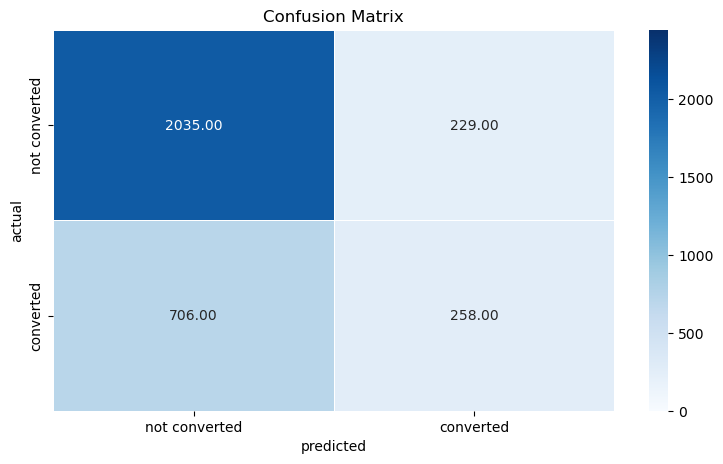

Testing Performance:
              precision    recall  f1-score   support

           0       0.74      0.91      0.82       971
           1       0.56      0.26      0.36       413

    accuracy                           0.72      1384
   macro avg       0.65      0.59      0.59      1384
weighted avg       0.69      0.72      0.68      1384



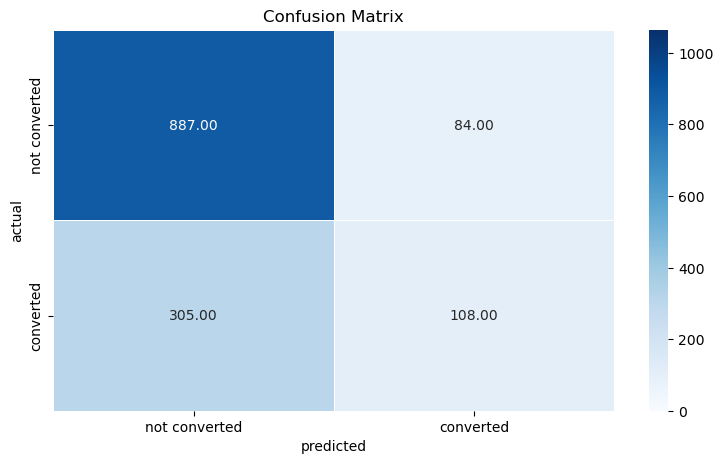

In [162]:
# Predicting on the training and testing data
y_train_pred_lr = model_lr.predict(X_train_scaled)
y_test_pred_lr = model_lr.predict(X_test_scaled)

# Evaluating the model on the training data
print("Training Performance:")

model_lr_train_metrics = metrics_score(y_train, y_train_pred_lr)

# Evaluating the model on the testing data
print("Testing Performance:")
model_lr_test_metrics = metrics_score(y_test, y_test_pred_lr)

### Hyperparameter Tuning

In [163]:
# Building a Logistic Regression model
model_lr_tuned = LogisticRegression(random_state=1, max_iter=1000)

In [164]:
# Define the parameter grid for logistic regression
param_grid_lr = {
    "C": [0.01, 0.1, 0.5, 1, 10, 100],
    "penalty": ["l1", "l2", "elasticnet"],
    "solver": ["saga", "liblinear"],
    "class_weight": ["balanced", {0: 0.3, 1: 0.70}],
}


# Initialize and run the grid search with cross-validation
gs_lr = GridSearchCV(model_lr_tuned, param_grid_lr, scoring="recall", cv=6, n_jobs=-1)
gs_lr = gs_lr.fit(X_train_scaled, y_train)

# Get the best parameters and best score
best_params_lr = gs_lr.best_params_
best_score_lr = gs_lr.best_score_

print(f"Best Parameters: {best_params_lr}")
print(f"Best Recall Score: {best_score_lr:.4f}")

Best Parameters: {'C': 0.1, 'class_weight': {0: 0.3, 1: 0.7}, 'penalty': 'l1', 'solver': 'liblinear'}
Best Recall Score: 0.5769


In [165]:
# Update the classifier with the best found parameters
model_lr_tuned = gs_lr.best_estimator_

# Fit the tuned model on the training data
model_lr_tuned.fit(X_train_scaled, y_train)

LogisticRegression(C=0.1, class_weight={0: 0.3, 1: 0.7}, max_iter=1000,
                   penalty='l1', random_state=1, solver='liblinear')

### Evaluating Model Performance 

Training Performance with Best Estimator:
              precision    recall  f1-score   support

           0       0.81      0.76      0.78      2264
           1       0.50      0.57      0.54       964

    accuracy                           0.70      3228
   macro avg       0.65      0.67      0.66      3228
weighted avg       0.72      0.70      0.71      3228



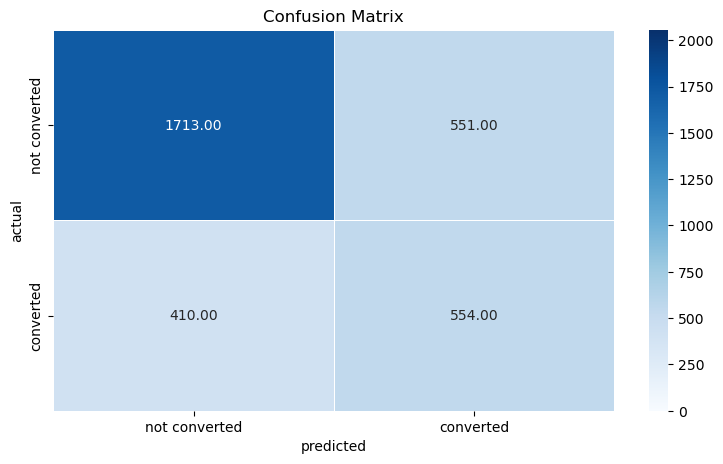

Testing Performance with Best Estimator:
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       971
           1       0.52      0.60      0.56       413

    accuracy                           0.71      1384
   macro avg       0.67      0.68      0.67      1384
weighted avg       0.73      0.71      0.72      1384



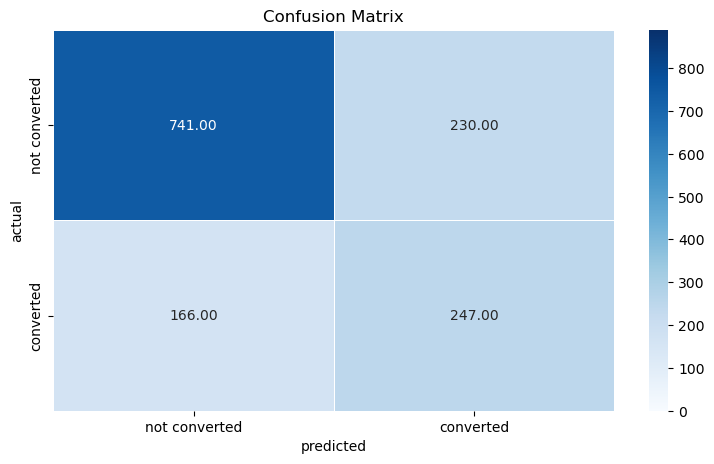

In [166]:
# Predict on the training and testing data using the best estimator
y_train_pred_lr_tuned = model_lr_tuned.predict(X_train_scaled)
y_test_pred_lr_tuned = model_lr_tuned.predict(X_test_scaled)

# Evaluate the model on the training data
print("Training Performance with Best Estimator:")
model_lr_tuned_train_metrics = metrics_score(y_train, y_train_pred_lr_tuned)

# Evaluate the model on the testing data
print("Testing Performance with Best Estimator:")
model_lr_tuned_test_metrics = metrics_score(y_test, y_test_pred_lr_tuned)

In [167]:
# Extract the coefficients
coefficients_lr = model_lr.coef_[0]

# Normalize the coefficients to sum to 1 (considering magnitude and direction)
relative_importance_lr = coefficients_lr / np.sum(np.abs(coefficients_lr))

# Get the feature names from the original DataFrame
features = X_train_numeric.columns

# Create a DataFrame to display the feature importance
importance_df = pd.DataFrame(
    relative_importance_lr, index=features, columns=["relative_importance"]
).sort_values(by="relative_importance", ascending=False)

print("Feature Importances | Logistic Regression")
print("-" * 52)
print(importance_df)
print("-" * 52)

Feature Importances | Logistic Regression
----------------------------------------------------
                       relative_importance
time_spent_on_website             0.601117
age                               0.282195
page_views_per_visit             -0.047148
website_visits                   -0.069540
----------------------------------------------------


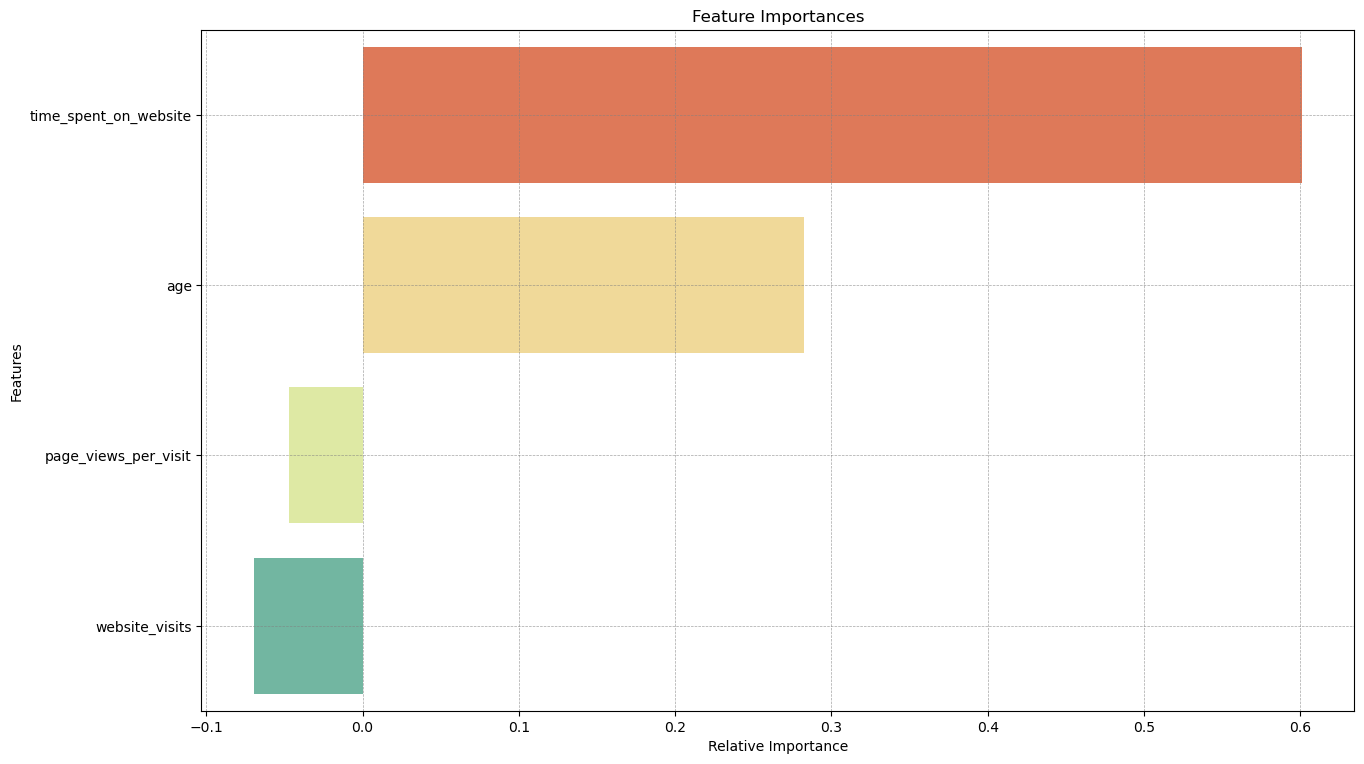

In [168]:
# Plot the feature importance
plt.figure(figsize=(14, 8))
plt.title("Feature Importances")
sns.barplot(
    data=importance_df,
    x="relative_importance",
    y=importance_df.index,
    palette="Spectral",
)
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.grid(True, color="grey", linestyle="--", linewidth=0.5, alpha=palette_alpha)

# Adjust layout and show the plot
plt.tight_layout(pad=2.0)
plt.show()

## Decision Tree

### Building Decision Tree Model

In [169]:
# Building Decision Tree model
model_dt = DecisionTreeClassifier(random_state=1)

# Fitting the model on the training data
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

### Evaluating Model Performance 

Training Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



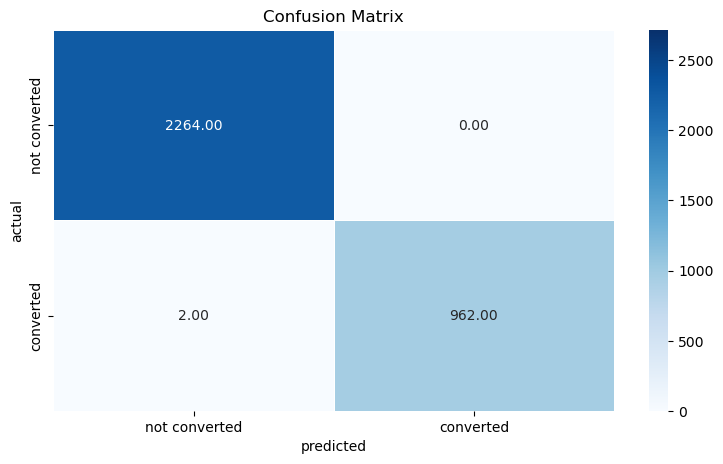

Testing Performance:
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       971
           1       0.67      0.65      0.66       413

    accuracy                           0.80      1384
   macro avg       0.76      0.76      0.76      1384
weighted avg       0.80      0.80      0.80      1384



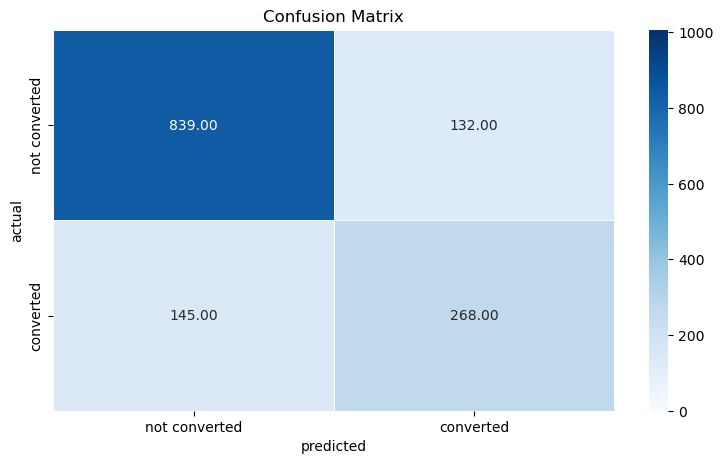

In [170]:
# Predicting on the training and testing data
y_train_pred_dt = model_dt.predict(X_train)
y_test_pred_dt = model_dt.predict(X_test)

# Evaluating the model on the training data
print("Training Performance:")
model_dt_train_metrics = metrics_score(y_train, y_train_pred_dt)

# Evaluating the model on the testing data
print("Testing Performance:")
model_dt_test_metrics = metrics_score(y_test, y_test_pred_dt)

**Observations**: 

- The decision tree reveals a perfect score for all metrics on the training dataset, demonstrating the nature of decision trees to grow and classify each data point correctly when no restrictions are applied, effectively capturing the underlying patterns of the training data.
- The confusion matrix shows only 2 false negatives, indicating minimal errors in predicting converted leads.

**Observations**: 
- The decision tree works perfectly on the training data but **not so well on the test data**, with an significant reduction of metric scores indicating overfitting the training data.
- Recall for converted leads is 0.65, indicating the model misses 35% of actual converted leads, classifying them as non-converted.
- Precision for converted leads is 0.67, indicating that 33% of leads predicted as converted are actually non-converted.
- The imbalance in the target variable (metric support value) contributes to the disparity in metrics and overall model performance on the minority class (converted leads).
- Hyperparameter tuning can reduce the overfitting and thereby increase the overall performance of the model. 
- Potential hyperparameter candidates for this decisiont tree model are class_weight, max_depth, min_sample_leaf, criterion.
- The confusion matrix shows a significant number of misclassifications, with 132 false positives and 145 false negatives, indicating substantial errors in predicting both converted and non-converted leads.

### Hyperparameter Tuning

**Imbalance in Target Variable**

The imbalance in the target variable can be addressed by setting the **class_weight** hyperparameter to the inverse binary ratio {0: 0.3, 1: 0.7}, which places more importance on the converted leads (class 1) in the model.

**Hyperparameter Tuning**

Hyperparameter tuning is achieved by using GridSearchCV to optimze the best set of parameters for the given model and data.
- **max_depth**: Specifies the maximum depth of the decision tree, controlling how many levels the tree can have, which impacts model complexity and overfitting.
- **criterion**: Defines the function used to measure the quality of a split in the decision tree, with options ‘gini’ for the Gini impurity and ‘entropy’ for information gain.
- **min_samples_leaf**: Sets the minimum number of samples that a node must have to be a leaf, affecting the granularity of the splits and potentially preventing overfitting by ensuring leaf nodes have enough samples.

In [171]:
# Building the decision tree model with initial parameters
model_dt_tuned = DecisionTreeClassifier(random_state=1, class_weight={0: 0.3, 1: 0.70})

In [172]:
# Define the grid of parameters to search
param_grid_dt = {
    "max_depth": list(range(2, 10)),
    "criterion": ["gini", "entropy"],
    "min_samples_leaf": [5, 10, 20, 25],
}

# Initialize and run the grid search with cross-validation
gs_dt = GridSearchCV(model_dt_tuned, param_grid_dt, scoring="recall", n_jobs=-1, cv=5)
gs_dt = gs_dt.fit(X_train, y_train)

# Get the best parameters and best score
best_params_dt = gs_dt.best_params_
best_score_dt = gs_dt.best_score_

print(f"Best Parameters: {best_params_dt}")
print(f"Best Recall Score: {best_score_dt:.4f}")

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5}
Best Recall Score: 0.9067


In [173]:
# Update the classifier with the best found parameters
model_dt_tuned = gs_dt.best_estimator_

# Fit the tuned model on the training data
model_dt_tuned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=3, min_samples_leaf=5, random_state=1)

### Evaluating Model Performance 

Training Performance with Best Estimator:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      2264
           1       0.60      0.91      0.72       964

    accuracy                           0.79      3228
   macro avg       0.78      0.83      0.78      3228
weighted avg       0.85      0.79      0.80      3228



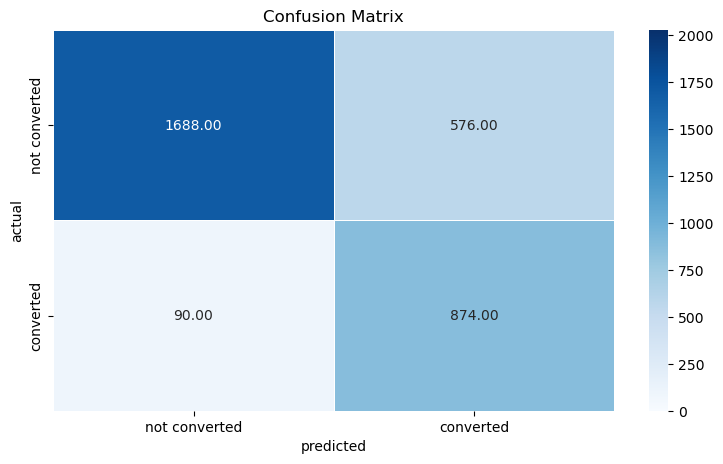

Testing Performance with Best Estimator:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82       971
           1       0.58      0.89      0.70       413

    accuracy                           0.78      1384
   macro avg       0.76      0.81      0.76      1384
weighted avg       0.83      0.78      0.79      1384



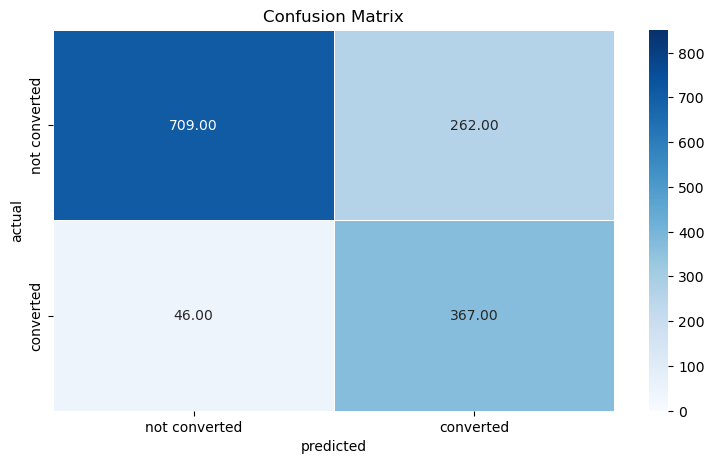

In [174]:
# Checking model performance on the training dataset
y_train_pred_dt_tuned = model_dt_tuned.predict(X_train)
y_test_pred_dt_tuned = model_dt_tuned.predict(X_test)

# Evaluate the model on the training data
print("Training Performance with Best Estimator:")
model_dt_tuned_train_metrics = metrics_score(y_train, y_train_pred_dt_tuned)

# Evaluate the model on the testing data
print("Testing Performance with Best Estimator:")
model_dt_tuned_test_metrics = metrics_score(y_test, y_test_pred_dt_tuned)

**Observations**:

- The original decision tree model exhibited perfect performance metrics and minimal misclassifications, indicating overfitting and poor generalization on the training data.
- The tuned model presented more balanced and realistic performance metrics on the training data, with both true-positives and false-positives in the confusion matrix, suggesting improved generalization within the training set.
- The overall accuracy of 0.79, recall of 0.91, and F1 score of 0.72 for the converted class indicate better generalization and an effective reduction of false negatives.
- The confusion matrix reveals 90 false-negatives and 576 false-positives on the training data, reflecting a trade-off to capture more true-positives.

**Observations**:
- The decision tree model’s performance on the test data is slightly lower than on the training data, with an accuracy of 0.78. 
- This drop in overall performance (accuracy, F1 score) is expected and indicates the model is generalizing reasonably well.
- The model achieves high recall for the converted class on both training and test data, with values of 0.91 and 0.89 respectively, effectively minimizing false-negatives.
- Precision for the converted class is moderate on both training and test data, with values of 0.60 and 0.58 respectively, indicating a significant number of false-positives, reflecting a trade-off made to improve recall.

### Visualization of Decision Tree

**Important Information**
- Depth: Hyperparameter tuning restricted the maximum depth to a specific range, preventing the decision tree from growing until nodes are homogeneous.
- Color Intensity: Darker colors indicate purer nodes, while lighter colors indicate mixed nodes.
- Color: The specific colors correspond to different classes (blue: converted leads y[1], orange: non-converted leads y[0]).
- Node Information: Each node contains information about the split criterion, entropy (or impurity), number of samples, class distribution, and the majority class.

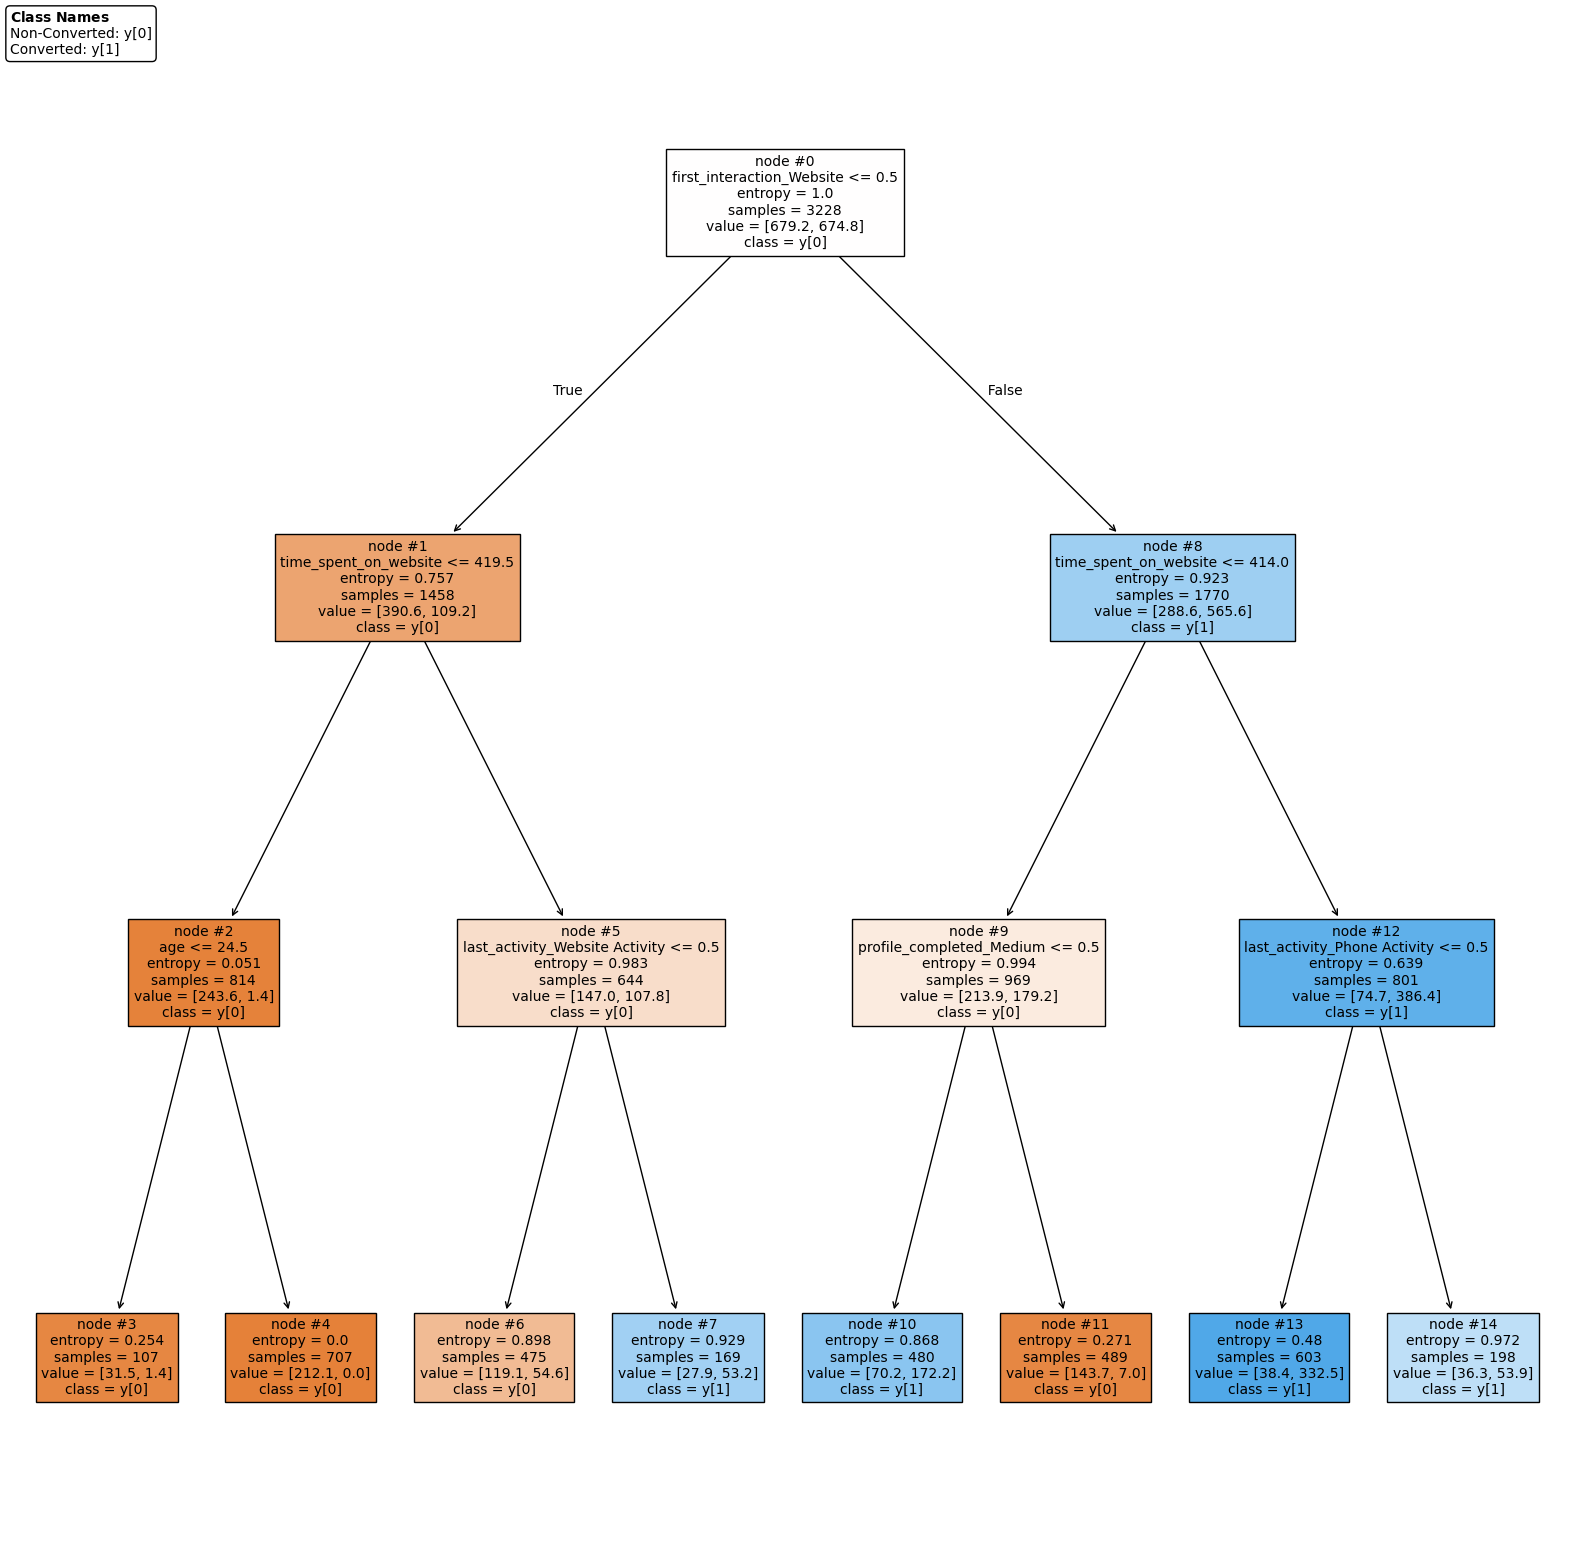

In [175]:
# Visualizing of the decision tree and the observed decision rules
features = X_train.columns.tolist()

plt.figure(figsize=(20, 20))
tree.plot_tree(
    model_dt_tuned,
    feature_names=features,
    filled=True,
    fontsize=10,
    node_ids=True,
    class_names=True,
)

# Add annotation to the figure
plt.annotate(
    r"$\mathbf{Class\ Names}$" + "\n" + "Non-Converted: y[0]\nConverted: y[1]",
    xy=(0, 1),
    xycoords="axes fraction",
    fontsize=10,
    ha="left",
    va="top",
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"),
)
plt.show()

**Observations**:
- The decision tree's hierarchical structure demonstrates the importance of certain features based on decision rules and the greedy algorithm.
- The tuned model is built to a depth of three levels, with key features being the initial interaction, followed by engagement time and other variables in predicting lead conversion.
- Each path, representing a sequence of nodes from root to leaf, defines a classification rule with specific features for a subset of data records.
- Each leaf node represents the final classification label, determined by the majority rule. The closer the entropy is to zero, the more homogeneous the outcomes are.

### Feature Importance

In [176]:
# Get the feature names from the original DataFrame
features = X_train.columns

# Extract the feature importances
importances = model_dt_tuned.feature_importances_

# Create a DataFrame to display the feature importance
importance_df = pd.DataFrame(
    importances, index=features, columns=["relative_importance"]
).sort_values(by="relative_importance", ascending=False)

print("Feature Importances | Decision Tree")
print("-" * 52)
print(importance_df)
print("-" * 52)

Feature Importances | Decision Tree
----------------------------------------------------
                                relative_importance
time_spent_on_website                      0.365546
first_interaction_Website                  0.313484
profile_completed_Medium                   0.233702
last_activity_Phone Activity               0.048402
last_activity_Website Activity             0.032013
age                                        0.006853
website_visits                             0.000000
page_views_per_visit                       0.000000
current_occupation_Student                 0.000000
current_occupation_Unemployed              0.000000
profile_completed_Low                      0.000000
print_media_type1_Yes                      0.000000
print_media_type2_Yes                      0.000000
digital_media_Yes                          0.000000
educational_channels_Yes                   0.000000
referral_Yes                               0.000000
---------------------------

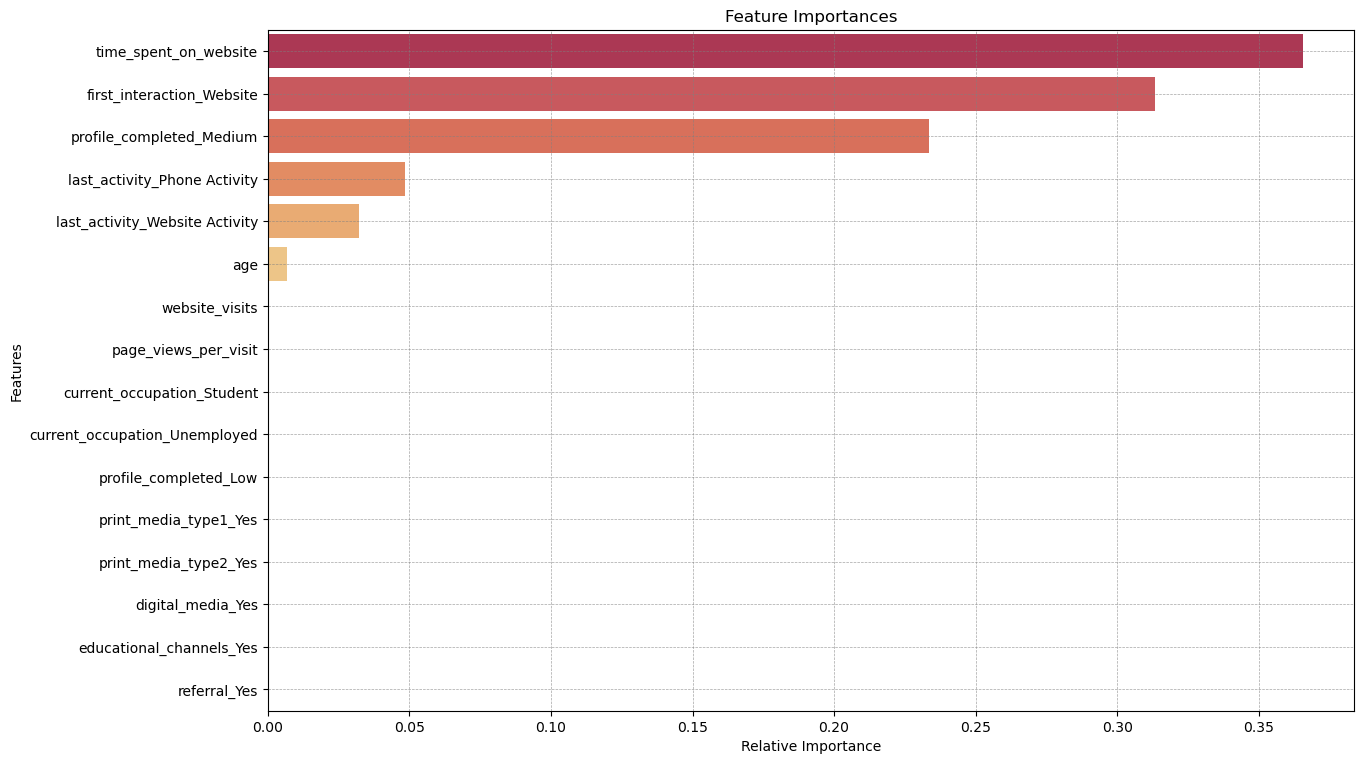

In [177]:
# Plot the feature importance
plt.figure(figsize=(14, 8))
plt.title("Feature Importances")
sns.barplot(
    data=importance_df,
    x="relative_importance",
    y=importance_df.index,
    palette="Spectral",
)
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.grid(True, color="grey", linestyle="--", linewidth=0.5, alpha=palette_alpha)

# Adjust layout and show the plot
plt.tight_layout(pad=2.0)
plt.show()

**Observations**:

Visualization of each feature's overall importance (an aggregate measure), considering its contribution to all splits in the decision tree model. 
- **time_spent_on_website, first_interaction_website and profile_completed_medium**: The three most important features, indicating that the amount of time users spend on the website and their initial interaction channel significantly impact lead conversion.
- **last_activity**: Particularly phone and website activities also play crucial roles in predicting lead conversion.
- **Other features**: The rest of the features have lower or no importance in this model.

## Random Forest

### Building Random Forest Model

In [178]:
# Building Random Forest model
model_rf = RandomForestClassifier(random_state=1)

# Fitting the model on the training data
model_rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

### Evaluating Model Performance 

Training Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2264
           1       1.00      1.00      1.00       964

    accuracy                           1.00      3228
   macro avg       1.00      1.00      1.00      3228
weighted avg       1.00      1.00      1.00      3228



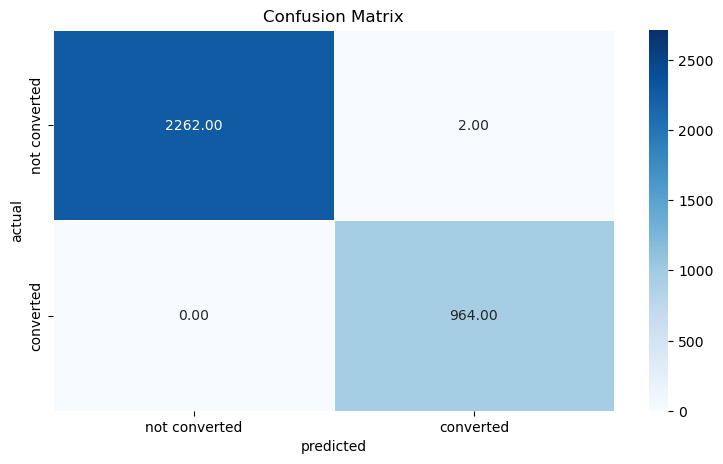

Testing Performance:
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       971
           1       0.78      0.72      0.75       413

    accuracy                           0.86      1384
   macro avg       0.83      0.82      0.83      1384
weighted avg       0.86      0.86      0.86      1384



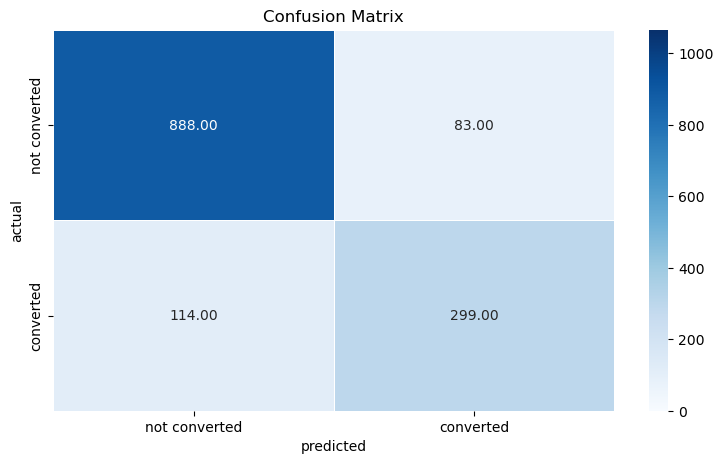

In [179]:
# Predicting on the training and testing data
y_train_pred_rf = model_rf.predict(X_train)
y_test_pred_rf = model_rf.predict(X_test)

# Evaluating the model on the training data
print("Training Performance:")
model_rf_train_metrics = metrics_score(y_train, y_train_pred_rf)

# Evaluating the model on the testing data
print("Testing Performance:")
model_rf_test_metrics = metrics_score(y_test, y_test_pred_rf)

**Observations**: 

- The random forest model reveals a perfect score for all metrics on the training dataset, effectively capturing the underlying patterns of the training data.
- The confusion matrix shows only 2 false-positive, indicating minimal errors in predicting non-converted leads.

**Observations**:

- The random forest model shows a reduction in metric scores on the test data, with an accuracy of 86%, indicating potential overfitting on the training data.
- Recall for converted leads is 0.72, suggesting the model misses 28% of actual converted leads, classifying them as non-converted.
- Precision for converted leads is 0.78, indicating that 22% of leads predicted as converted are actually non-converted.
- The imbalance in the target variable (metric support value) contributes to the disparity in metrics and overall model performance on the minority class (converted leads).
- Hyperparameter tuning can reduce the overfitting and thereby increase the overall performance of the model. 
- The confusion matrix shows 114 false-negatives, reflecting the model's challenge in correctly identifying all converted leads.

### Hyperparameter Tuning

Hyperparameter tuning is achieved by using GridSearchCV to optimze the best set of parameters for the given model and data.
- **n_estimators**: Specifies the number of trees in the random forest, controlling the size of the ensemble.
- **max_depth**: Specifies the maximum depth of the decision tree, controlling how many levels the tree can have, which impacts model complexity and overfitting.
- **min_samples_leaf**: Sets the minimum number of samples that a node must have to be a leaf, affecting the granularity of the splits and potentially preventing overfitting by ensuring leaf nodes have enough samples.
- **max_features**: Determines the maximum number of features to consider when looking for the best split in each tree.
- **max_samples**: Specifies the number of samples to draw from the training data to train each individual tree.

In [180]:
# Building the random forest model with initial parameters
model_rf_tuned = RandomForestClassifier(
    random_state=1, criterion="entropy", class_weight={0: 0.3, 1: 0.70}
)

In [181]:
# Define the grid of parameters to search
param_grid_rf = {
    "n_estimators": [100, 150],
    "max_depth": [6, 7],
    "min_samples_leaf": [5, 10, 20, 25],
    "max_features": [0.8, 0.9],
    "max_samples": [0.9, 1],
}

# Initialize and run the grid search with cross-validation
gs_rf = GridSearchCV(model_rf_tuned, param_grid_rf, scoring="recall", cv=6, n_jobs=-1)
gs_rf = gs_rf.fit(X_train, y_train)

# Get the best parameters and best score
best_params_rf = gs_rf.best_params_
best_score_rf = gs_rf.best_score_

print(f"Best Parameters: {best_params_rf}")
print(f"Best Recall Score: {best_score_rf:.4f}")

Best Parameters: {'max_depth': 7, 'max_features': 0.8, 'max_samples': 0.9, 'min_samples_leaf': 25, 'n_estimators': 100}
Best Recall Score: 0.8754


In [182]:
# Update the classifier with the best found parameters
model_rf_tuned = gs_rf.best_estimator_

# Fit the tuned model on the training data
model_rf_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.3, 1: 0.7}, criterion='entropy',
                       max_depth=7, max_features=0.8, max_samples=0.9,
                       min_samples_leaf=25, random_state=1)

### Evaluating Model Performance 

Training Performance with Best Estimator:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      2264
           1       0.68      0.88      0.77       964

    accuracy                           0.84      3228
   macro avg       0.81      0.85      0.82      3228
weighted avg       0.86      0.84      0.85      3228



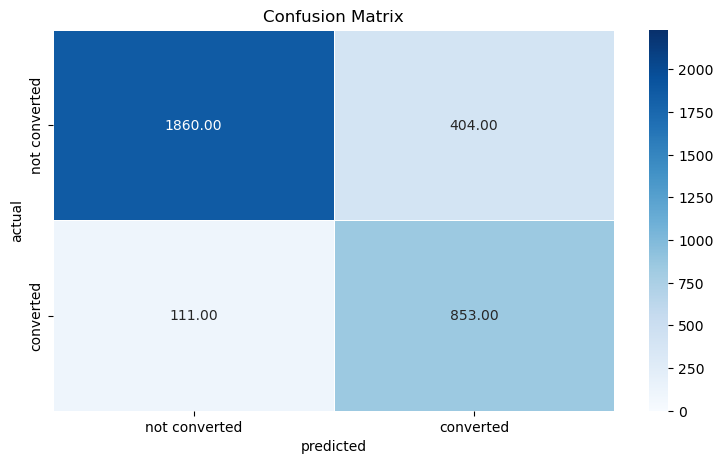

Testing Performance with Best Estimator:
              precision    recall  f1-score   support

           0       0.92      0.81      0.86       971
           1       0.65      0.84      0.74       413

    accuracy                           0.82      1384
   macro avg       0.79      0.83      0.80      1384
weighted avg       0.84      0.82      0.83      1384



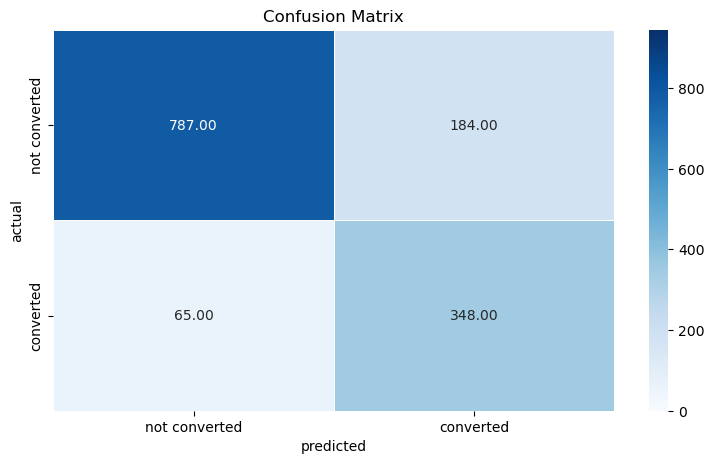

In [183]:
# Predict on the training and testing data using the best estimator
y_train_pred_rf_tuned = model_rf_tuned.predict(X_train)
y_test_pred_rf_tuned = model_rf_tuned.predict(X_test)

# Evaluate the model on the training data
print("Training Performance with Best Estimator:")
model_rf_tuned_train_metrics = metrics_score(y_train, y_train_pred_rf_tuned)

# Evaluate the model on the testing data
print("Testing Performance with Best Estimator:")
model_rf_tuned_test_metrics = metrics_score(y_test, y_test_pred_rf_tuned)

**Observations**:

- The original random forest model showed perfect performance metrics and minimal misclassifications, indicating overfitting and poor generalization on the training data.
- The tuned model presented more balanced and realistic performance metrics on the training data, with both true-positives and false-positives in the confusion matrix, suggesting improved generalization within the training set.
- The overall accuracy of 0.84, recall of 0.89, and F1 score of 0.77 for the converted class indicate better generalization and effective reduction of false-negatives.
- The confusion matrix reveals 108 false-negatives and 412 false-positives on the training data, reflecting a trade-off to capture more true-positives.

**Observations**:
- The random forest model’s performance on the test data is slightly lower than on the training data, with an accuracy of 0.82. 
- This drop in overall performance (accuracy, F1 score) is expected and indicates the model is generalizing reasonably well.
- The model achieves high recall for the converted class on both training and test data, with values of 0.91 and 0.85 respectively, effectively minimizing false-negatives.
- Precision for the converted class is moderate on both training and test data, with values of 0.68 and 0.65 respectively, indicating a significant number of false-positives, reflecting a trade-off made to improve recall.

**Note**:
Limiting the random forest model in the hyperparameter tuning to a maximum depth of 3 yields performance metrics similar to the decision tree.<br>
This is because both models heavily rely on the same top three features. This adjustment achieves a recall of 0.89 on the test data for converted leads, but at the cost of increasing false positives.

### Visualization of Random Forest

The major downside of implementing ensemble methods is that the ability to obtain an interpretation of the model and its decision rules is lost. However, the feature importance can still be extracted and analysed.


In [184]:
# Get the feature names from the original DataFrame
features = X_train.columns

# Extract the feature importances
importances = model_rf_tuned.feature_importances_


importance_df = pd.DataFrame(
    importances, index=features, columns=["relative_importance"]
).sort_values(by="relative_importance", ascending=False)

print("Feature Importances | Random Forest")
print("-" * 52)
print(importance_df)
print("-" * 52)

Feature Importances | Random Forest
----------------------------------------------------
                                relative_importance
time_spent_on_website                  3.021489e-01
first_interaction_Website              2.708121e-01
profile_completed_Medium               1.943884e-01
age                                    5.390522e-02
last_activity_Website Activity         4.746169e-02
last_activity_Phone Activity           4.391225e-02
current_occupation_Unemployed          3.792340e-02
page_views_per_visit                   2.088440e-02
current_occupation_Student             1.624782e-02
website_visits                         1.011832e-02
educational_channels_Yes               1.175952e-03
profile_completed_Low                  5.552910e-04
digital_media_Yes                      2.971793e-04
print_media_type1_Yes                  1.691158e-04
print_media_type2_Yes                  1.398172e-18
referral_Yes                           0.000000e+00
---------------------------

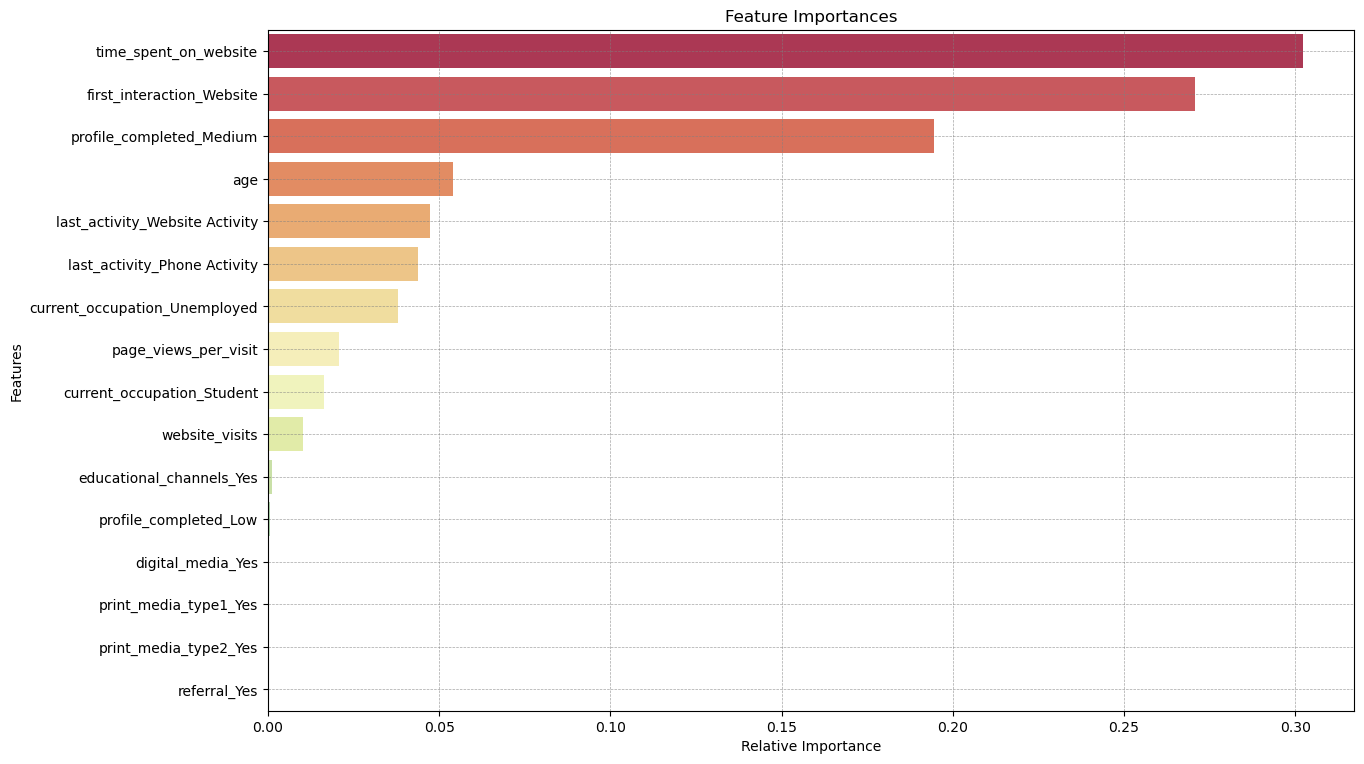

In [185]:
# Plot the feature importance
plt.figure(figsize=(14, 8))
plt.title("Feature Importances")
sns.barplot(
    data=importance_df,
    x="relative_importance",
    y=importance_df.index,
    palette="Spectral",
)
plt.xlabel("Relative Importance")
plt.ylabel("Features")
plt.grid(True, color="grey", linestyle="--", linewidth=0.5, alpha=palette_alpha)

# Adjust layout and show the plot
plt.tight_layout(pad=2.0)
plt.show()

**Observations**:
- Both models identify the same top three features, **time_spent_on_website**, **first_interaction_Website**, **profile_completed_Medium**, for predicting lead conversion, indicating these are robust predictors.
- The single decision tree shows a sharper drop-off in feature importance after the top features, while the random forest distributes importance more broadly across additional features, such as **age**, **current_occupation**, **page_views_per_visits**, **websites_visits** and **educational_channels** in its decision-making process.
- The random forest’s broader feature importance distribution makes it more robust and less prone to overfitting compared to the single decision tree, leading to better generalization.

---

## Model Comparison

In [186]:
def display_metrics(metrics, title):
    """
    Display the metrics in a formatted DataFrame.

    Args:
        metrics (dict): Dictionary containing the metrics.
        title (str): Title for the metrics display.
    """
    # Convert the metrics dictionary into a DataFrame
    metrics_df = pd.DataFrame(metrics).T

    # Capitalize the column names
    metrics_df.columns = metrics_df.columns.str.capitalize()

    # Display the DataFrame
    display(Markdown(f"**{title}**"))
    display(metrics_df)

In [187]:
# Define metric dictionaries

baseline_metrics = {
    "Logistic Regression": model_lr_test_metrics,
    "Decision Tree": model_dt_test_metrics,
    "Random Forest": model_rf_test_metrics,
}

tuned_metrics = {
    "Logistic Regression": model_lr_tuned_test_metrics,
    "Decision Tree": model_dt_tuned_test_metrics,
    "Random Forest": model_rf_tuned_test_metrics,
}


# Display baseline metrics
display_metrics(baseline_metrics, "Baseline Model Metrics")

# Display tuned metrics
display_metrics(tuned_metrics, "Tuned Model Metrics")

**Baseline Model Metrics**

,Accuracy,Precision,Recall,F1_score
Logistic Regression,0.719,0.562,0.262,0.357
Decision Tree,0.800,0.670,0.649,0.659
Random Forest,0.858,0.783,0.724,0.752


**Tuned Model Metrics**

,Accuracy,Precision,Recall,F1_score
Logistic Regression,0.714,0.518,0.598,0.555
Decision Tree,0.777,0.583,0.889,0.704
Random Forest,0.820,0.654,0.843,0.737


In [188]:
# Convert the dictionary to a DataFrame
tuned_metrics_df = pd.DataFrame(tuned_metrics).T

# Melt the DataFrame to along format for visualization
tuned_metrics_df.reset_index(inplace=True)
metrics_long = pd.melt(
    tuned_metrics_df, id_vars="index", var_name="Metric", value_name="Score"
)

# Rename columns for clarity
metrics_long.columns = ["Model", "Metric", "Score"]

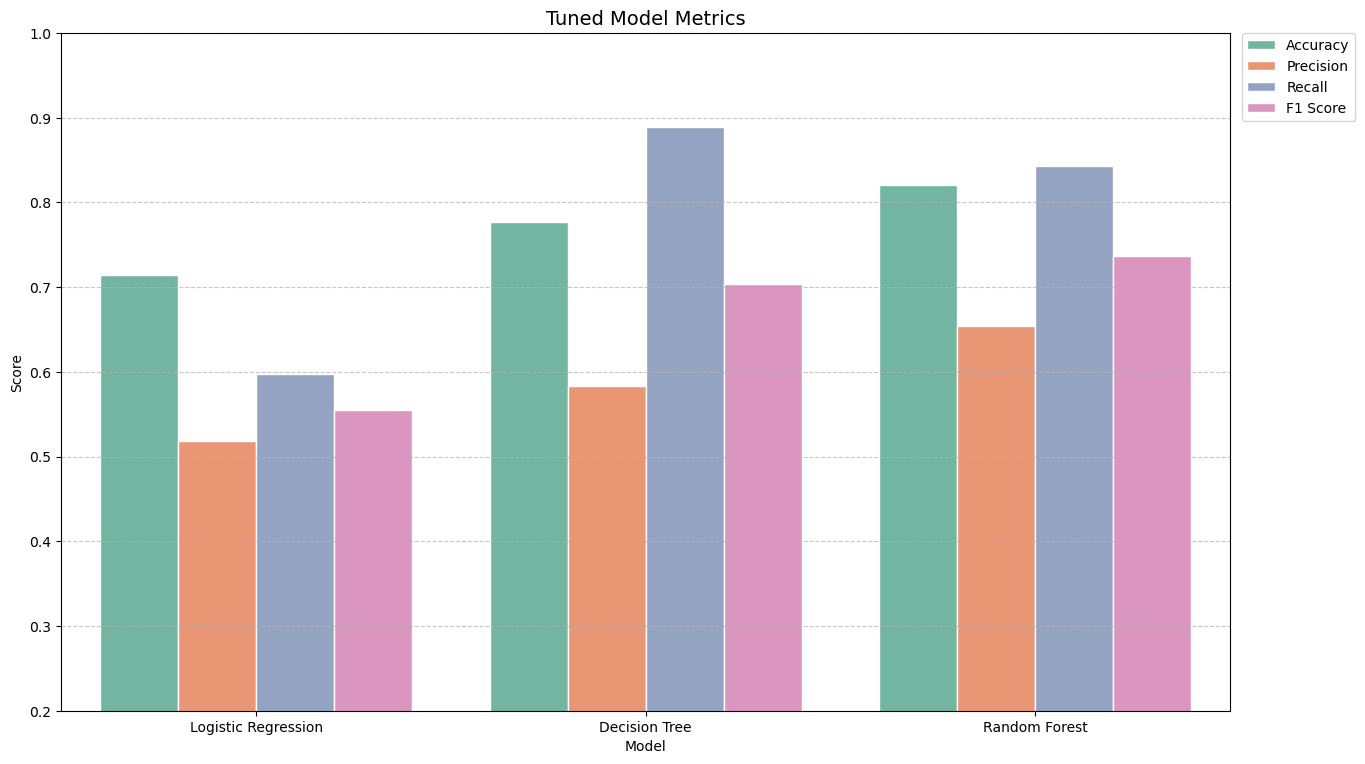

In [189]:
# Plot the metrics for the tuned models
plt.figure(figsize=(14, 8))
sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    palette=palette_color,
    data=metrics_long,
    edgecolor="white",
)

# Format legend entries
handles, labels = plt.gca().get_legend_handles_labels()
labels = [label.replace("_", " ").title() for label in labels]
plt.legend(
    handles, labels, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0.0
)

# Add a title and grid
plt.title("Tuned Model Metrics", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(0.2, 1)

# Adjust layout and show the plot
plt.tight_layout(pad=2.0)
plt.show()

---

## Conclusion and Recommendations

### Conclusion

**Machine Learning Models**

1. Both the single decision tree and random forest models identify the same top three features—**time_spent_on_website**, **first_interaction_Website**, and **profile_completed_Medium**—for predicting lead conversion. This consistency indicates that these features are robust predictors of lead conversion.

2. The random forest model distributes importance more broadly across additional features, such as **age**, **last_activity**, **current_occupation**, **page_views_per_visit**, **website_visits**, and **educational_channels**. This broader feature importance distribution enhances its robustness and reduces overfitting, leading to better generalization.

3. The random forest model exhibits higher overall performance on the test data, with an accuracy of 0.82 and an F1 score of 0.74 compared to the single decision tree's accuracy of 0.78 and F1 score of 0.70. However, it shows a slightly reduced recall, 0.85 compared to 0.89, leading to marginally more false negatives and potentially missing some leads that could convert. Increasing recall often involves a trade-off with precision and overall performance.

**Lead Conversion Characteristics**

Based on the exploratory data analysis and model results, the following aspects should be considered to identify leads with a high potential for conversion to paid customers.

1. **Demographic Profiles**:
    - Age: Typically between 30-60 years.
    - Occupation: Mostly professionals and unemployed individuals.
2. **Behavioral Profile**:
    - First Interaction Channel: Predominantly interacted first via the website.
    - Profile Completion: High completion rate (75-100%) or Medium completion rate (50-75%).
    - Last Activity: Recent interactions through email are associated with higher conversion rates.
3. **Engagement Metrics**:
    - Time Spent on Website: Significant amount of time spent on the website.
    - Website Visits: Frequent visits to the website.
    - Page Views per Visit: High number of pages viewed per visit.
4. **Referral Status**:
    - Leads who have been referred by others are more likely to convert.

### Business Recommendations

1. **Enhance Website Engagement**: 
    - Focus on improving the user experience on the website to encourage longer visits and more page views.
	- Simplify navigation and improve website design to make it more intuitive and engaging.
	- Ensure the website is mobile-responsive and loads quickly to reduce bounce rates.
2. **Profile Completion**:
	- Implement new features on the website that prompt users to complete their profiles.
	- Streamline the profile completion process by reducing the number of steps and fields required.
	- Provide clear instructions and tooltips to help users understand the importance of each profile section.
3. **Optimize Interaction Channels**:
	- Prioritize website interactions and emails as they show higher conversion rates.
	- Reassess the approach to mobile app interactions to increase their effectiveness.
4. **Targeted Marketing**:
	- Tailor marketing strategies to professionals and unemployed individuals who show higher conversion rates.
	- Use LinkedIn and other professional networks to reach this audience with targeted ads and content.
	- Offer student discounts and flexible payment plans to make courses more accessible.
	- Collaborate with educational institutions to integrate courses into their curricula or offer them as supplementary material.
5. **Leverage Referral Programs**:
	- Only two percent of all potential leads make use of the referral option (therefore not considered in models) 
	- Develop and promote referral programs to leverage on the high conversion rates from referrals. 
	- Use social media integration to allow users to refer friends directly from their social platforms.
6. **Continuous Model Improvement**:
	- Regularly update and tune the predictive models to maintain high accuracy in lead conversion predictions.
	- Use model insights to refine lead nurturing strategies continuously.


---